In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pprint import pprint
from scipy import stats
from functools import reduce
#import dash_bio
import pyarrow
import math
from scipy.stats import linregress

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#from gseapy.plot import barplot, dotplot
import gseapy as gp
from gseapy import Msigdb

from tqdm import tqdm

from datetime import datetime
today = datetime.today().strftime('%Y-%m-%d')

%matplotlib inline
pd.set_option('display.max_columns', None)

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

sns.set(font_scale=1.5)
sns.set_style("ticks")

In [2]:
# Change the file name below to your input file name
input_file_name = 'diann_report.parquet'


In [3]:
df = pd.read_parquet(input_file_name)
df = df.loc[:,['Run', 'Protein.Ids', 'Genes', 'Genes.MaxLFQ']]
df.head()

,Run,Protein.Ids,Genes,Genes.MaxLFQ
0,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,P55011,SLC12A2,853670.250
1,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,P55011,SLC12A2,3459751.000
2,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,P55011,SLC12A2,2124395.500
3,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,P55011,SLC12A2,3553067.500
4,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,P55011,SLC12A2,559945.375


In [4]:
df = df.sort_values('Genes')
df.head()

,Run,Protein.Ids,Genes,Genes.MaxLFQ
150828,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,,,0.0
4215169,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,,,0.0
4215170,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,,,0.0
4215171,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,,,0.0
4215172,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,,,0.0


In [5]:
df = df[df['Protein.Ids'] != '']
df = df[df['Genes.MaxLFQ'] > 0]
df.head()

,Run,Protein.Ids,Genes,Genes.MaxLFQ
3504192,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,P04217,A1BG,14159833.0
2288105,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,P04217,A1BG,9495944.0
2288243,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,P04217,A1BG,11790384.0
2288242,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,P04217,A1BG,38363716.0
2288241,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,P04217,A1BG,10283613.0


In [6]:
df_p = df.pivot_table(columns='Run', index=['Genes', 'Protein.Ids'], values='Genes.MaxLFQ')
df_p.columns = df_p.columns.str.split('/').str[-1].str.split('.').str[0]
#df_p.index = df_p.index.droplevel(0)
df_p = df_p.reset_index()
df_p = df_p.drop('Protein.Ids', axis=1)

# Identical intensity values for rows with same gene ids
df_p = df_p.groupby('Genes').mean()
df_p.head()

Run,001_BR-LF-3_C21,002_BR-LF-3_C21,003_BR-LF-3_C21,004_BR-LF-3_C21,005_BR-LF-3_C21,006_BR-LF-3_C21,007_BR-LF-3_C21,009_BR-LF-3_C21,010_BR-LF-3_C21,011_BR-LF-3_C21,012_BR-LF-3_C21,013_BR-LF-3_C21,014_BR-LF-3_C21,015_BR-LF-3_C21,016_BR-LF-3_C21,017_BR-LF-3_C21,018_BR-LF-3_C21,019_BR-LF-3_C21,020_BR-LF-3_C21,021_BR-LF-3_C21,022_BR-LF-3_C21,023_BR-LF-3_C21,024_BR-LF-3_C21,025_BR-LF-3_C21,026_BR-LF-3_C21,027_BR-LF-3_C21,028_BR-LF-3_C21,029_BR-LF-3_C21,030_BR-LF-3_C21,031_BR-LF-3_C21,032_BR-LF-3_C21,033r_BR-LF-3_C21,034_BR-LF-3_C21,035_BR-LF-3_C21,036_BR-LF-3_C21,037_BR-LF-3_C21,038_BR-LF-3_C21,039_BR-LF-3_C21,040_BR-LF-3_C21,041_BR-LF-3_C21,042rr_BR-LF-3_C21,043r_BR-LF-3_C21,044r_BR-LF-3_C21,045_BR-LF-3_C21,046_BR-LF-3_C21,047_BR-LF-3_C21,048_BR-LF-3_C21,049_BR-LF-3_C21,050_BR-LF-3_C21,051_BR-LF-3_C21,052_BR-LF-3_C21,053_BR-LF-3_C21,054_BR-LF-3_C21,055_BR-LF-3_C21,056_BR-LF-3_C21,057_BR-LF-3_C21,058_BR-LF-3_C21,059_BR-LF-3_C21,060_BR-LF-3_C21,061_BR-LF-3_C21,062_BR-LF-3_C21,063_BR-LF-3_C21,064_BR-LF-3_C21,065_BR-LF-3_C21,066_BR-LF-3_C21,067_BR-LF-3_C21,068_BR-LF-3_C21,069_BR-LF-3_C21,070_BR-LF-3_C21,071_BR-LF-3_C21,072_BR-LF-3_C21,075_BR-LF-3_C21,076_BR-LF-3_C21,077_BR-LF-3_C21,078_BR-LF-3_C21,079_BR-LF-3_C21,080_BR-LF-3_C21,081_BR-LF-3_C21,082_BR-LF-3_C21,083_BR-LF-3_C21,084_BR-LF-3_C21,085_BR-LF-3_C21,086_BR-LF-3_C21,087_BR-LF-3_C21,088_BR-LF-3_C21,089_BR-LF-3_C21,090_BR-LF-3_C21
Genes,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A1BG,1.415983e+07,8.007314e+06,9.238439e+06,1.158742e+07,6.786722e+07,1.169070e+07,9.457809e+06,1.621317e+07,1.725236e+07,1.179038e+07,1.010994e+07,7518505.50,5.666861e+06,7.647497e+06,8.750481e+06,1.693017e+07,1.039707e+07,91138016.00,1.587965e+07,1.283040e+07,1.316018e+07,9.750561e+06,9.493675e+06,1.658682e+07,1.479854e+07,6.461748e+06,1.176604e+07,3.539138e+06,9702346.0,1.340876e+07,9.495944e+06,8.399520e+06,1.218609e+07,4.809785e+06,1.573540e+07,1.875407e+07,3.059399e+06,2.185674e+07,1.281333e+07,8.651317e+06,3.678095e+06,1.038516e+07,3.836372e+07,1.269596e+07,1.260378e+07,1.028847e+07,5.466080e+06,1.247959e+07,8.189069e+06,1.202197e+07,2.802897e+06,7782070.5,5.759026e+06,9.165085e+06,1.760136e+07,1.567541e+07,3.289515e+06,8.755992e+06,1.326863e+07,1.495960e+08,1.003395e+07,1.092786e+07,1.395744e+07,4.724683e+06,1.809171e+07,32057912.0,8.694835e+06,4.940282e+06,9.536635e+06,1.480877e+07,1.307888e+07,1.287013e+07,5.539462e+06,6.677308e+06,1.038387e+07,7.588890e+06,1.028361e+07,5.167290e+06,28818828.0,9.272374e+06,7.190888e+06,7.320879e+06,1.675270e+07,6.470358e+06,3.043786e+06,6.614857e+06,7.582634e+06
A1CF,6.448770e+06,4.860955e+06,6.769131e+06,1.015831e+07,1.311846e+06,9.083397e+06,9.767649e+05,7.023427e+06,6.008126e+06,8.649671e+06,5.920692e+06,11191245.00,3.745305e+06,8.402021e+06,8.041535e+06,6.769586e+06,7.854978e+06,3211827.75,8.098624e+06,4.950510e+06,6.944696e+06,5.508478e+06,6.948834e+06,5.589164e+06,9.344943e+06,9.021345e+06,8.803793e+06,5.339518e+06,5197923.0,1.140788e+06,9.008524e+06,5.611082e+06,8.242566e+06,4.603184e+06,1.255583e+06,7.018874e+06,5.356386e+05,9.321489e+06,4.672882e+06,7.358254e+06,4.986300e+06,6.008818e+06,5.249470e+06,7.080298e+06,8.155707e+06,1.089494e+07,5.196292e+06,9.424597e+06,5.302786e+06,9.609692e+06,7.688736e+06,8266942.5,5.993386e+06,1.102555e+07,1.103000e+06,9.673000e+06,3.561497e+06,8.063090e+06,3.139133e+06,2.446991e+06,1.142147e+06,8.202646e+06,1.236959e+06,8.875897e+05,1.732176e+06,NaN,9.045006e+06,3.334749e+06,1.149372e+07,5.191089e+06,9.122267e+06,8.282014e+06,3.825088e+06,9.991120e+06,7.671779e+06,8.132899e+06,1.167887e+07,3.014370e+06,15626361.0,1.252600e+07,4.641609e+06,7.751669e+06,4.622462e+06,8.700995e+06,5.986438e+06,8.763455e+06,8.279877e+06
A2M,4.617809e+07,3.489649e+07,3.742978e+07,2.139801e+07,1.745632e+08,1.274894e+07,1.154769e+07,3.820005e+07,3.122601e+07,4.364952e+07,1.823655e+07,20156808.00,2.070955e+07,8.535370e+06,8.625021e+06,2.265544e+07,2.081696e+07,98747928.00,9.053980e+07,1.104437e+08,6.724

In [7]:
df_p.shape

(8124, 87)

In [8]:
# New sample mapping with clinical features
meta = pd.read_csv('../sample_mapping_BvR.csv')
# We only do HCC
meta = meta[meta['Tumor diagnosis'] == 'HCC']
# Only take patients were we have all transcriptome samples
prot_cols = ['Biopsy_nt_proteome', 'Biopsy_tu_proteome',
             'Resection_nt_protome', 'Resection_tu_protome']
meta = meta.dropna(subset=prot_cols)


# Identified a problematic sample (big outlier by PCA) and decided to remove it from the dataset
meta = meta[meta['Patient ID'] != 'F']

# Remove smaple with large tim ebeteen biopsy and resection
meta = meta[meta['Patient ID'] != 'C']

# Additional sample outliers in HCC dataset, samples with low amount of identifications
meta = meta[~meta['Patient ID'].isin(['P','U','J'])]

meta.head()

,Patient ID,Biopsy_nt_transcriptome,Biopsy_tu_transcriptome,Resection_nt_transcriptome,Resection_tu_transcriptome,Biopsy_nt_proteome,Biopsy_tu_proteome,Resection_nt_protome,Resection_tu_protome,Biopsy_nt_phospho,Biopsy_tu_phospho,Resection_nt_phospho,Resection_tu_phospho,Age,Sex,PreBx_MELD,PreBx_ALAT,PreBx_ASAT,PreBx_GGT,PreBx_AP,PreBx_Albumin,PreBx_Bilirubin,PreBx_Quick,PreBx_Hb,PreBx_Lc,PreBx_Tc,PreBx_CRP,PreBx_AFP,PreOP_MELD,PreOP_ALAT,PreOP_ASAT,PreOP_GGT,PreOP_AP,PreOP_Albumin,PreOP_Bilirubin,PreOP_Quick,PreOP_Hb,PreOP_Lc,PreOP_Tc,PreOP_CRP,PreOP_AFP,CHILD,BCLC,Nr of nodules,Max nodule size,Time between resection and biopsy,Total surgery time = ischemia time,Tumor diagnosis,Biopsy_nt_hepatocyte,Resection_nt_hepatocyte,Biopsy_nt_stroma,Resection_nt_stroma,Biopsy_tu_tumor,Resection_tu_tumor,Biopsy_tu_stroma,Resection_tu_stroma,Biopsy_tu_necrosis,Resection_tu_necrosis,Biopsy_tu_nontumor,Resection_tu_nontumor
7,D,BSSE_QGF_182052,BSSE_QGF_182053,BSSE_QGF_182082,BSSE_QGF_182083,011_BR-LF-3_C21,012_BR-LF-3_C21,032_BR-LF-3_C21,033r_BR-LF-3_C21,011_BR-LF-3P_PO4_C21,012_BR-LF-3P_PO4_C21,032_BR-LF-3P_PO4_C21,033_BR-LF-3P_PO4_C21,70.0,F,6.0,29.0,22.0,23.0,82.0,41.0,9.0,94.0,147.0,11.0,254.0,0.3,2.0,6.0,22.0,20.0,22.0,93.0,42.0,11.0,95.0,139.0,11.0,284.0,0.3,NaN,NaN,A,1,23.0,29.0,87.0,HCC,84.0,87.0,16.0,13.0,47.0,97.0,29.0,3.0,0.0,0.0,24.0,0.0
9,E,BSSE_QGF_145476,BSSE_QGF_145477,BSSE_QGF_145478,BSSE_QGF_145479,075_BR-LF-3_C21,076_BR-LF-3_C21,087_BR-LF-3_C21,088_BR-LF-3_C21,075_BR-LF-3P_PO4_C21,076_BR-LF-3P_PO4_C21,087_BR-LF-3P_PO4_C21,088_BR-LF-3P_PO4_C21,79.0,M,6.0,18.0,26.0,167.0,80.0,39.0,10.0,94.0,127.0,5.0,139.0,3.0,12.0,7.0,26.0,28.0,149.0,83.0,38.0,9.0,87.0,139.0,6.0,184.0,2.0,NaN,NaN,A,2,29.0,31.0,149.0,HCC,93.0,90.0,7.0,10.0,61.0,99.0,19.0,1.0,5.0,0.0,15.0,0.0
17,I,BSSE_QGF_182072,BSSE_QGF_182073,BSSE_QGF_182106,BSSE_QGF_182107,024_BR-LF-3_C21,025_BR-LF-3_C21,053_BR-LF-3_C21,054_BR-LF-3_C21,024_BR-LF-3P_PO4_C21,025_BR-LF-3P_PO4_C21,053_BR-LF-3P_PO4_C21,054_BR-LF-3P_PO4_C21,54.0,F,6.0,35.0,34.0,53.0,92.0,39.0,5.0,91.0,148.0,8.0,142.0,2.0,4.0,6.0,37.0,33.0,44.0,79.0,36.0,6.0,91.0,129.0,6.0,140.0,1.2,NaN,A,A,1,55.0,30.0,157.0,HCC,84.0,94.0,16.0,6.0,75.0,99.0,17.0,1.0,0.0,0.0,8.0,0.0
23,L,BSSE_QGF_145460,BSSE_QGF_145461,BSSE_QGF_145462,BSSE_QGF_145463,071_BR-LF-3_C21,072_BR-LF-3_C21,084_BR-LF-3_C21,085_BR-LF-3_C21,071r_BR-LF-3P_PO4_C21,072r_BR-LF-3P_PO4_C21,084_BR-LF-3P_PO4_C21,085_BR-LF-3P_PO4_C21,66.0,F,8.0,14.0,28.0,86.0,63.0,20.0,14.0,70.0,115.0,8.0,90.0,21.0,NaN,8.0,15.0,26.0,68.0,73.0,29.0,14.0,75.0,140.0,8.0,111.0,22.0,NaN,A,A,1,28.0,18.0,67.0,HCC,47.0,74.0,53.0,26.0,96.0,91.0,4.0,9.0,0.0,0.0,0.0,0.0
27,N,BSSE_QGF_182054,BSSE_QGF_182055,BSSE_QGF_182084,BSSE_QGF_182085,013_BR-LF-3_C21,014_BR-LF-3_C21,034_BR-LF-3_C21,035_BR-LF-3_C21,013_BR-LF-3P_PO4_C21,014_BR-LF-3P_PO4_C21,034_BR-LF-3P_PO4_C21,035_BR-LF-3P_PO4_C21,60.0,M,6.0,12.0,24.0,33.0,99.0,42.0,3.0,0.0,137.0,6.0,220.0,0.6,NaN,6.0,18.0,29.0,202.0,163.0,44.0,7.0,93.0,148.0,13.0,302.0,3.0,NaN,NaN,A,2,15.0,15.0,108.0,HCC,96.0,74.0,4.0,26.0,64.0,50.0,24.0,50.0,12.0,0.0,0.0,0.0


In [11]:
# Check if we have all proteome samples in the spectronout output
found = []
for group in prot_cols:
    for seq_id in meta[group]:
        if seq_id in df_p.columns:
            found.append(seq_id)
        else:
            print('missing:', seq_id)

In [12]:
# Extras
extras = []
for seq_id in df_p.columns:
    if seq_id in found:
        continue
    else:
        print('extra:', seq_id)
        extras.append(seq_id)
df_ = df_p.drop(extras, axis=1)

extra: 001_BR-LF-3_C21
extra: 002_BR-LF-3_C21
extra: 003_BR-LF-3_C21
extra: 004_BR-LF-3_C21
extra: 005_BR-LF-3_C21
extra: 006_BR-LF-3_C21
extra: 007_BR-LF-3_C21
extra: 009_BR-LF-3_C21
extra: 010_BR-LF-3_C21
extra: 015_BR-LF-3_C21
extra: 016_BR-LF-3_C21
extra: 017_BR-LF-3_C21
extra: 018_BR-LF-3_C21
extra: 019_BR-LF-3_C21
extra: 028_BR-LF-3_C21
extra: 029_BR-LF-3_C21
extra: 030_BR-LF-3_C21
extra: 031_BR-LF-3_C21
extra: 036_BR-LF-3_C21
extra: 037_BR-LF-3_C21
extra: 038_BR-LF-3_C21
extra: 039_BR-LF-3_C21
extra: 040_BR-LF-3_C21
extra: 041_BR-LF-3_C21
extra: 042rr_BR-LF-3_C21
extra: 043r_BR-LF-3_C21
extra: 044r_BR-LF-3_C21
extra: 045_BR-LF-3_C21
extra: 046_BR-LF-3_C21
extra: 055_BR-LF-3_C21
extra: 056_BR-LF-3_C21
extra: 057_BR-LF-3_C21
extra: 058_BR-LF-3_C21
extra: 059_BR-LF-3_C21
extra: 060_BR-LF-3_C21
extra: 061_BR-LF-3_C21
extra: 062_BR-LF-3_C21
extra: 063_BR-LF-3_C21
extra: 064_BR-LF-3_C21
extra: 065_BR-LF-3_C21
extra: 066_BR-LF-3_C21
extra: 067_BR-LF-3_C21
extra: 068_BR-LF-3_C21
extra: 

In [14]:
meta_prot = meta.loc[:,['Patient ID', 'Biopsy_nt_proteome', 'Biopsy_tu_proteome',
                        'Resection_nt_protome', 'Resection_tu_protome',
                        'Age', 'Sex','Time between resection and biopsy',
                        'Total surgery time = ischemia time']].copy()
meta_prot = meta_prot.melt(id_vars=['Patient ID', 'Age', 'Sex',
                                  'Time between resection and biopsy',
                                  'Total surgery time = ischemia time'],
                         value_vars=prot_cols)
meta_prot['Sample_type'] = meta_prot.variable.str.split('_').str[0]
meta_prot['Tissue'] = np.where(meta_prot.variable.str.contains('nt'), 'non-tumor', 'tumor')
meta_prot = meta_prot.drop('variable', axis=1)
meta_prot = meta_prot.rename({'value':'Seq_id', 'Total surgery time = ischemia time': 'Total surgery time',
                           'Patient ID': 'patient_id'}, axis=1)

# biopsy dont have surgery time
meta_prot['Total surgery time'] = np.where(meta_prot['Sample_type'] == 'Biopsy', 0, meta_prot['Total surgery time'])

# Make new column with column names
meta_prot['col_names'] = meta_prot.Tissue.str\
                            .cat(meta_prot.Sample_type.str\
                                .cat(meta_prot.patient_id, sep='_'), sep='_')
meta_prot.index = meta_prot.Seq_id
meta_prot = meta_prot.sort_index()

meta_prot.head()

,patient_id,Age,Sex,Time between resection and biopsy,Total surgery time,Seq_id,Sample_type,Tissue,col_names
Seq_id,,,,,,,,,
011_BR-LF-3_C21,D,70,F,29,0.0,011_BR-LF-3_C21,Biopsy,non-tumor,non-tumor_Biopsy_D
012_BR-LF-3_C21,D,70,F,29,0.0,012_BR-LF-3_C21,Biopsy,tumor,tumor_Biopsy_D
013_BR-LF-3_C21,N,60,M,15,0.0,013_BR-LF-3_C21,Biopsy,non-tumor,non-tumor_Biopsy_N
014_BR-LF-3_C21,N,60,M,15,0.0,014_BR-LF-3_C21,Biopsy,tumor,tumor_Biopsy_N
020_BR-LF-3_C21,O,78,M,28,0.0,020_BR-LF-3_C21,Biopsy,non-tumor,non-tumor_Biopsy_O


In [15]:
df_.columns

Index(['011_BR-LF-3_C21', '012_BR-LF-3_C21', '013_BR-LF-3_C21',
       '014_BR-LF-3_C21', '020_BR-LF-3_C21', '021_BR-LF-3_C21',
       '022_BR-LF-3_C21', '023_BR-LF-3_C21', '024_BR-LF-3_C21',
       '025_BR-LF-3_C21', '026_BR-LF-3_C21', '027_BR-LF-3_C21',
       '032_BR-LF-3_C21', '033r_BR-LF-3_C21', '034_BR-LF-3_C21',
       '035_BR-LF-3_C21', '047_BR-LF-3_C21', '048_BR-LF-3_C21',
       '049_BR-LF-3_C21', '050_BR-LF-3_C21', '051_BR-LF-3_C21',
       '052_BR-LF-3_C21', '053_BR-LF-3_C21', '054_BR-LF-3_C21',
       '071_BR-LF-3_C21', '072_BR-LF-3_C21', '075_BR-LF-3_C21',
       '076_BR-LF-3_C21', '084_BR-LF-3_C21', '085_BR-LF-3_C21',
       '087_BR-LF-3_C21', '088_BR-LF-3_C21'],
      dtype='object', name='Run')

In [16]:
new_col_names = {}
for col in df_.columns:
    #print(col)
    new_col_names[col] = meta_prot.loc[col,'col_names']

In [17]:
df_n = df_.rename(new_col_names, axis=1)

In [18]:
df_n.head()

Run,non-tumor_Biopsy_D,tumor_Biopsy_D,non-tumor_Biopsy_N,tumor_Biopsy_N,non-tumor_Biopsy_O,tumor_Biopsy_O,non-tumor_Biopsy_Q,tumor_Biopsy_Q,non-tumor_Biopsy_I,tumor_Biopsy_I,non-tumor_Biopsy_T,tumor_Biopsy_T,non-tumor_Resection_D,tumor_Resection_D,non-tumor_Resection_N,tumor_Resection_N,non-tumor_Resection_O,tumor_Resection_O,non-tumor_Resection_Q,tumor_Resection_Q,non-tumor_Resection_T,tumor_Resection_T,non-tumor_Resection_I,tumor_Resection_I,non-tumor_Biopsy_L,tumor_Biopsy_L,non-tumor_Biopsy_E,tumor_Biopsy_E,non-tumor_Resection_L,tumor_Resection_L,non-tumor_Resection_E,tumor_Resection_E
Genes,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A1BG,1.179038e+07,1.010994e+07,7518505.50,5.666861e+06,1.587965e+07,1.283040e+07,1.316018e+07,9.750561e+06,9.493675e+06,1.658682e+07,1.479854e+07,6.461748e+06,9.495944e+06,8.399520e+06,1.218609e+07,4.809785e+06,1.028847e+07,5.466080e+06,1.247959e+07,8.189069e+06,1.202197e+07,2.802897e+06,7782070.5,5.759026e+06,1.480877e+07,1.307888e+07,1.287013e+07,5.539462e+06,7.190888e+06,7.320879e+06,6.470358e+06,3.043786e+06
A1CF,8.649671e+06,5.920692e+06,11191245.00,3.745305e+06,8.098624e+06,4.950510e+06,6.944696e+06,5.508478e+06,6.948834e+06,5.589164e+06,9.344943e+06,9.021345e+06,9.008524e+06,5.611082e+06,8.242566e+06,4.603184e+06,1.089494e+07,5.196292e+06,9.424597e+06,5.302786e+06,9.609692e+06,7.688736e+06,8266942.5,5.993386e+06,5.191089e+06,9.122267e+06,8.282014e+06,3.825088e+06,4.641609e+06,7.751669e+06,8.700995e+06,5.986438e+06
A2M,4.364952e+07,1.823655e+07,20156808.00,2.070955e+07,9.053980e+07,1.104437e+08,6.724698e+07,4.718387e+07,2.007096e+07,4.133306e+07,1.737056e+07,8.301864e+06,1.661965e+07,1.578017e+07,3.476998e+07,1.020478e+07,2.809669e+07,1.125419e+07,4.857088e+07,3.284584e+07,1.140552e+07,2.945464e+06,10409178.0,6.973845e+06,6.077596e+07,3.596558e+07,6.738936e+07,1.825130e+07,1.516867e+07,9.101573e+06,1.507495e+07,9.818649e+06
AAAS,1.930956e+05,1.976801e+05,135839.25,1.860286e+05,1.435312e+05,3.535504e+05,1.712246e+05,2.846154e+05,1.679320e+05,1.597825e+05,2.222466e+05,2.479780e+05,7.746666e+04,1.563139e+05,1.453289e+05,2.376617e+05,1.734218e+05,2.810483e+05,1.985452e+05,2.772920e+05,2.229346e+05,1.735794e+05,NaN,2.022325e+05,1.745695e+05,1.914647e+05,1.552130e+05,2.927351e+05,1.451798e+05,1.378502e+05,1.137160e+05,2.390194e+05
AACS,NaN,NaN,NaN,NaN,NaN,2.885578e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.100928e+04,NaN,NaN,NaN,NaN,NaN,NaN,6.982902e+04,NaN,NaN,9.724155e+04,NaN,NaN,NaN,9.310825e+04


In [19]:
# Sort column names
sample_names = sorted(df_n.columns)
#other_cols = ['PG.ProteinGroups', 'PG.Genes']
col_order = sample_names
df_n = df_n[col_order]
print(df_n.columns)
print(df_n.shape)

Index(['non-tumor_Biopsy_D', 'non-tumor_Biopsy_E', 'non-tumor_Biopsy_I',
       'non-tumor_Biopsy_L', 'non-tumor_Biopsy_N', 'non-tumor_Biopsy_O',
       'non-tumor_Biopsy_Q', 'non-tumor_Biopsy_T', 'non-tumor_Resection_D',
       'non-tumor_Resection_E', 'non-tumor_Resection_I',
       'non-tumor_Resection_L', 'non-tumor_Resection_N',
       'non-tumor_Resection_O', 'non-tumor_Resection_Q',
       'non-tumor_Resection_T', 'tumor_Biopsy_D', 'tumor_Biopsy_E',
       'tumor_Biopsy_I', 'tumor_Biopsy_L', 'tumor_Biopsy_N', 'tumor_Biopsy_O',
       'tumor_Biopsy_Q', 'tumor_Biopsy_T', 'tumor_Resection_D',
       'tumor_Resection_E', 'tumor_Resection_I', 'tumor_Resection_L',
       'tumor_Resection_N', 'tumor_Resection_O', 'tumor_Resection_Q',
       'tumor_Resection_T'],
      dtype='object', name='Run')
(8124, 32)


In [20]:
df_n.isna().sum()

Run
non-tumor_Biopsy_D       2995
non-tumor_Biopsy_E       3239
non-tumor_Biopsy_I       2097
non-tumor_Biopsy_L       2563
non-tumor_Biopsy_N       3427
non-tumor_Biopsy_O       3176
non-tumor_Biopsy_Q       2590
non-tumor_Biopsy_T       2712
non-tumor_Resection_D    2600
non-tumor_Resection_E    2941
non-tumor_Resection_I    2748
non-tumor_Resection_L    2136
non-tumor_Resection_N    2667
non-tumor_Resection_O    2722
non-tumor_Resection_Q    2808
non-tumor_Resection_T    3043
tumor_Biopsy_D           2482
tumor_Biopsy_E           2134
tumor_Biopsy_I           3261
tumor_Biopsy_L           3006
tumor_Biopsy_N           1833
tumor_Biopsy_O           3883
tumor_Biopsy_Q           2337
tumor_Biopsy_T           2116
tumor_Resection_D        2743
tumor_Resection_E        2198
tumor_Resection_I        2347
tumor_Resection_L        2578
tumor_Resection_N        2224
tumor_Resection_O        1851
tumor_Resection_Q        2433
tumor_Resection_T        2398
dtype: int64

In [21]:
protein_count = {}
for sample in sample_names:
    protein_count[sample] = df_n[sample].dropna().shape[0]
    
df_out = pd.DataFrame.from_dict(protein_count, orient='index').T
#df_out.to_csv('protein_count.csv')

In [22]:
df_out.T

,0
non-tumor_Biopsy_D,5129
non-tumor_Biopsy_E,4885
non-tumor_Biopsy_I,6027
non-tumor_Biopsy_L,5561
non-tumor_Biopsy_N,4697
non-tumor_Biopsy_O,4948
non-tumor_Biopsy_Q,5534
non-tumor_Biopsy_T,5412
non-tumor_Resection_D,5524
non-tumor_Resection_E,5183


<Axes: >

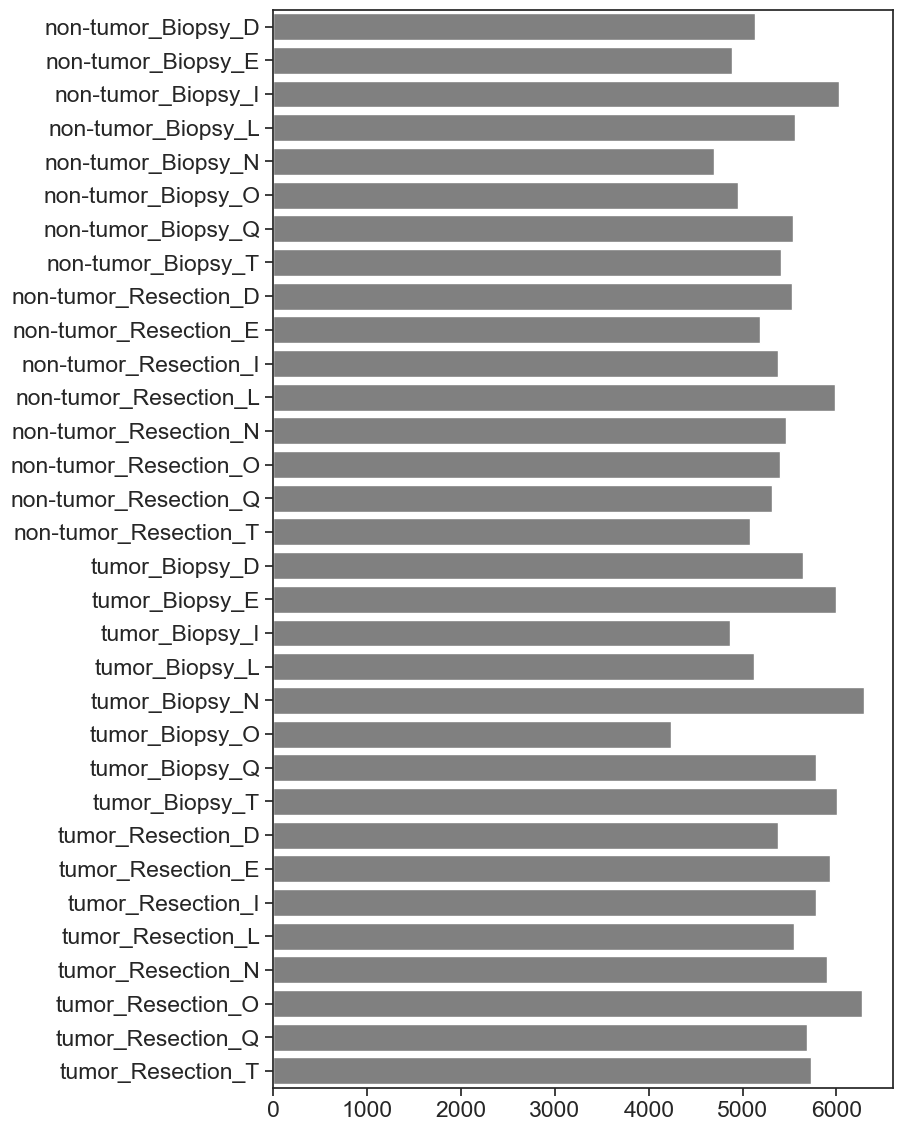

In [23]:
fig, ax = plt.subplots(figsize=(8,14))
sns.barplot(df_out, color='grey', orient='h')
#plt.savefig('figures/protein_ids_per_sample.png')

## Split samples by tissue

In [24]:
metadata = meta_prot.loc[:,['Sample_type', 'Sex', 'Age', 'Tissue',
                           'Seq_id', 'patient_id', 'col_names',
                           'Time between resection and biopsy',
                           'Total surgery time']].copy()
metadata.index = metadata.Seq_id
metadata_liver = metadata[metadata.Tissue == 'non-tumor'].copy()
metadata_hcc = metadata[metadata.Tissue == 'tumor'].copy()

In [25]:
metadata_liver.head()

,Sample_type,Sex,Age,Tissue,Seq_id,patient_id,col_names,Time between resection and biopsy,Total surgery time
Seq_id,,,,,,,,,
011_BR-LF-3_C21,Biopsy,F,70,non-tumor,011_BR-LF-3_C21,D,non-tumor_Biopsy_D,29,0.0
013_BR-LF-3_C21,Biopsy,M,60,non-tumor,013_BR-LF-3_C21,N,non-tumor_Biopsy_N,15,0.0
020_BR-LF-3_C21,Biopsy,M,78,non-tumor,020_BR-LF-3_C21,O,non-tumor_Biopsy_O,28,0.0
022_BR-LF-3_C21,Biopsy,F,70,non-tumor,022_BR-LF-3_C21,Q,non-tumor_Biopsy_Q,32,0.0
024_BR-LF-3_C21,Biopsy,F,54,non-tumor,024_BR-LF-3_C21,I,non-tumor_Biopsy_I,30,0.0


In [26]:
# Log2 transform
df_log = np.log2(df_n)
df_log.head()

Run,non-tumor_Biopsy_D,non-tumor_Biopsy_E,non-tumor_Biopsy_I,non-tumor_Biopsy_L,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_T,non-tumor_Resection_D,non-tumor_Resection_E,non-tumor_Resection_I,non-tumor_Resection_L,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,tumor_Biopsy_D,tumor_Biopsy_E,tumor_Biopsy_I,tumor_Biopsy_L,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_T,tumor_Resection_D,tumor_Resection_E,tumor_Resection_I,tumor_Resection_L,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T
Genes,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A1BG,23.491108,23.617523,23.178535,23.819948,22.842014,23.920675,23.649675,23.818951,23.178881,22.625414,22.891722,22.777739,23.538733,23.294525,23.573067,23.519171,23.269272,22.401314,23.983534,23.640736,22.434118,23.613062,23.217054,22.623493,23.001875,21.537436,22.457394,22.803585,22.197540,22.382074,22.965267,21.418488
A1CF,23.044214,22.981550,22.728340,22.307606,23.415867,22.949245,22.727480,23.155754,23.102859,23.052750,22.978922,22.146194,22.974663,23.377155,23.167999,23.196058,22.497334,21.867062,22.414202,23.120960,21.836653,22.239145,22.393223,23.104912,22.419847,22.513266,22.514940,22.886076,22.134201,22.309052,22.338320,22.874315
A2M,25.379463,26.006018,24.258606,25.856997,24.264765,26.432049,26.002966,24.050140,23.986387,23.845650,23.311354,23.854591,25.051338,24.743896,25.533588,23.443228,24.120329,24.121496,25.300793,25.100113,24.303793,26.718737,25.491791,22.985004,23.911610,23.227093,22.733522,23.117685,23.282742,23.423960,24.969208,21.490063
AAAS,17.558956,17.243889,17.357517,17.413443,17.051540,17.131004,17.385530,17.761801,16.241287,16.795076,NaN,17.147482,17.148962,17.403925,17.599108,17.766260,17.592808,18.159237,17.285749,17.546719,17.505165,18.431557,18.118654,17.919853,17.254087,17.866768,17.625656,17.072742,17.858549,18.100458,18.081047,17.405237
AACS,NaN,NaN,NaN,16.091539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.569284,NaN,NaN,NaN,18.138500,NaN,NaN,NaN,16.506622,NaN,NaN,NaN,16.305799,NaN,NaN


In [27]:
df_liver = df_log.loc[:,metadata_liver.col_names].copy()
# df_liver['Gene'] = df_n['PG.Genes']
# df_liver['ID'] = df_n['PG.ProteinGroups']
# df_liver.index = df_liver.ID

df_hcc = df_log.loc[:,metadata_hcc.col_names].copy()
# df_hcc['Gene'] = df_n['PG.Genes']
# df_hcc['ID'] = df_n['PG.ProteinGroups']
# df_hcc.index = df_hcc.ID

In [28]:
df_log.shape[0] - df_log.isna().sum()

Run
non-tumor_Biopsy_D       5129
non-tumor_Biopsy_E       4885
non-tumor_Biopsy_I       6027
non-tumor_Biopsy_L       5561
non-tumor_Biopsy_N       4697
non-tumor_Biopsy_O       4948
non-tumor_Biopsy_Q       5534
non-tumor_Biopsy_T       5412
non-tumor_Resection_D    5524
non-tumor_Resection_E    5183
non-tumor_Resection_I    5376
non-tumor_Resection_L    5988
non-tumor_Resection_N    5457
non-tumor_Resection_O    5402
non-tumor_Resection_Q    5316
non-tumor_Resection_T    5081
tumor_Biopsy_D           5642
tumor_Biopsy_E           5990
tumor_Biopsy_I           4863
tumor_Biopsy_L           5118
tumor_Biopsy_N           6291
tumor_Biopsy_O           4241
tumor_Biopsy_Q           5787
tumor_Biopsy_T           6008
tumor_Resection_D        5381
tumor_Resection_E        5926
tumor_Resection_I        5777
tumor_Resection_L        5546
tumor_Resection_N        5900
tumor_Resection_O        6273
tumor_Resection_Q        5691
tumor_Resection_T        5726
dtype: int64

In [29]:
# QC

metadata_qc = metadata.copy()
metadata_qc.index = metadata_qc.col_names

metadata_qc['counts'] = df_log.shape[0] - df_log.isna().sum()

In [30]:
metadata_qc.head()

,Sample_type,Sex,Age,Tissue,Seq_id,patient_id,col_names,Time between resection and biopsy,Total surgery time,counts
col_names,,,,,,,,,,
non-tumor_Biopsy_D,Biopsy,F,70,non-tumor,011_BR-LF-3_C21,D,non-tumor_Biopsy_D,29,0.0,5129
tumor_Biopsy_D,Biopsy,F,70,tumor,012_BR-LF-3_C21,D,tumor_Biopsy_D,29,0.0,5642
non-tumor_Biopsy_N,Biopsy,M,60,non-tumor,013_BR-LF-3_C21,N,non-tumor_Biopsy_N,15,0.0,4697
tumor_Biopsy_N,Biopsy,M,60,tumor,014_BR-LF-3_C21,N,tumor_Biopsy_N,15,0.0,6291
non-tumor_Biopsy_O,Biopsy,M,78,non-tumor,020_BR-LF-3_C21,O,non-tumor_Biopsy_O,28,0.0,4948


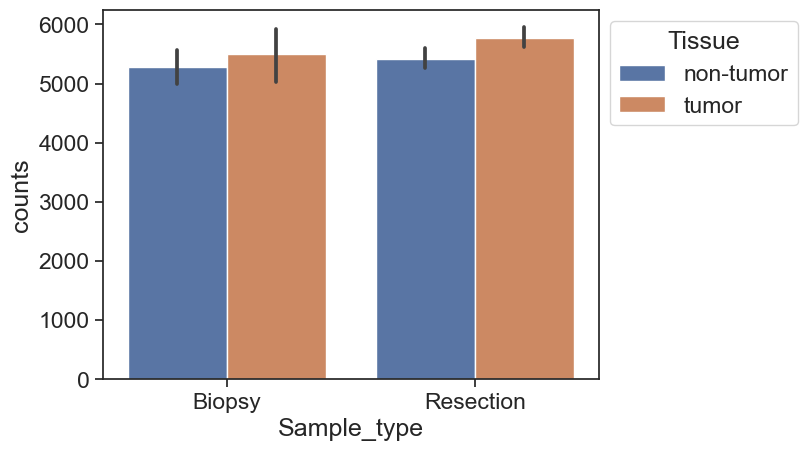

In [31]:
ax = sns.barplot(data=metadata_qc, x='Sample_type', y='counts', hue='Tissue')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

plt.savefig('proteomics_qc_protein_ids.pdf', bbox_inches='tight', dpi=300)


In [32]:
metadata_qc.head()

,Sample_type,Sex,Age,Tissue,Seq_id,patient_id,col_names,Time between resection and biopsy,Total surgery time,counts
col_names,,,,,,,,,,
non-tumor_Biopsy_D,Biopsy,F,70,non-tumor,011_BR-LF-3_C21,D,non-tumor_Biopsy_D,29,0.0,5129
tumor_Biopsy_D,Biopsy,F,70,tumor,012_BR-LF-3_C21,D,tumor_Biopsy_D,29,0.0,5642
non-tumor_Biopsy_N,Biopsy,M,60,non-tumor,013_BR-LF-3_C21,N,non-tumor_Biopsy_N,15,0.0,4697
tumor_Biopsy_N,Biopsy,M,60,tumor,014_BR-LF-3_C21,N,tumor_Biopsy_N,15,0.0,6291
non-tumor_Biopsy_O,Biopsy,M,78,non-tumor,020_BR-LF-3_C21,O,non-tumor_Biopsy_O,28,0.0,4948


In [33]:
res_list = []
for var in metadata_qc.Tissue.unique():
    subset = metadata_qc[metadata_qc.Tissue == var]
    print(var)
    res = stats.ttest_ind(subset[subset.Sample_type == 'Biopsy'].counts, subset[subset.Sample_type == 'Resection'].counts)
    print(res)
    print('\n')
    res_list.append(var)
    res_list.append(res)

    
import csv
    
with open('proteomics_qc_ttest.csv', 'w', newline='') as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(res_list)

non-tumor
TtestResult(statistic=-0.7764497440328134, pvalue=0.4504031411866969, df=14.0)


tumor
TtestResult(statistic=-1.0846649135867032, pvalue=0.2963958747455894, df=14.0)




# Imputation

In [34]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(
    n_neighbors=3,     # small k due to small sample size
    weights='uniform', # or 'distance' if closer samples should weigh more
    metric='nan_euclidean',  # default metric, handles missing values
    add_indicator=True
)
imputer.set_output(transform='pandas')

KNNImputer(add_indicator=True, n_neighbors=3)

In [35]:
# at least 4 valid values
df_liver = df_liver.dropna(thresh=4)
df_hcc = df_hcc.dropna(thresh=4)

In [36]:
df_liver.head()

Run,non-tumor_Biopsy_D,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_I,non-tumor_Biopsy_T,non-tumor_Resection_D,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,non-tumor_Resection_I,non-tumor_Biopsy_L,non-tumor_Biopsy_E,non-tumor_Resection_L,non-tumor_Resection_E
Genes,,,,,,,,,,,,,,,,
A1BG,23.491108,22.842014,23.920675,23.649675,23.178535,23.818951,23.178881,23.538733,23.294525,23.573067,23.519171,22.891722,23.819948,23.617523,22.777739,22.625414
A1CF,23.044214,23.415867,22.949245,22.727480,22.728340,23.155754,23.102859,22.974663,23.377155,23.167999,23.196058,22.978922,22.307606,22.981550,22.146194,23.052750
A2M,25.379463,24.264765,26.432049,26.002966,24.258606,24.050140,23.986387,25.051338,24.743896,25.533588,23.443228,23.311354,25.856997,26.006018,23.854591,23.845650
AAAS,17.558956,17.051540,17.131004,17.385530,17.357517,17.761801,16.241287,17.148962,17.403925,17.599108,17.766260,NaN,17.413443,17.243889,17.147482,16.795076
AADAC,22.635256,22.216269,21.702147,21.364202,21.940102,21.679272,20.697002,21.403500,21.187321,21.954636,21.140141,21.519085,21.075367,21.440708,20.574656,20.981941


In [37]:
df_liver.shape

(6176, 16)

In [38]:
df_hcc.shape

(6697, 16)

In [39]:
df_liver_biop = imputer.fit_transform(df_liver.loc[:,metadata_liver[metadata_liver.Sample_type == 'Biopsy'].col_names])
df_liver_rese = imputer.fit_transform(df_liver.loc[:,metadata_liver[metadata_liver.Sample_type == 'Resection'].col_names])

df_hcc_biop = imputer.fit_transform(df_hcc.loc[:,metadata_hcc[metadata_hcc.Sample_type == 'Biopsy'].col_names])
df_hcc_rese = imputer.fit_transform(df_hcc.loc[:,metadata_hcc[metadata_hcc.Sample_type == 'Resection'].col_names])

In [40]:
df_liver_biop.head()

,non-tumor_Biopsy_D,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_I,non-tumor_Biopsy_T,non-tumor_Biopsy_L,non-tumor_Biopsy_E,missingindicator_non-tumor_Biopsy_D,missingindicator_non-tumor_Biopsy_N,missingindicator_non-tumor_Biopsy_O,missingindicator_non-tumor_Biopsy_Q,missingindicator_non-tumor_Biopsy_I,missingindicator_non-tumor_Biopsy_T,missingindicator_non-tumor_Biopsy_L,missingindicator_non-tumor_Biopsy_E
Genes,,,,,,,,,,,,,,,,
A1BG,23.491108,22.842014,23.920675,23.649675,23.178535,23.818951,23.819948,23.617523,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A1CF,23.044214,23.415867,22.949245,22.727480,22.728340,23.155754,22.307606,22.981550,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A2M,25.379463,24.264765,26.432049,26.002966,24.258606,24.050140,25.856997,26.006018,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAAS,17.558956,17.051540,17.131004,17.385530,17.357517,17.761801,17.413443,17.243889,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AADAC,22.635256,22.216269,21.702147,21.364202,21.940102,21.679272,21.075367,21.440708,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [41]:
df_hcc_biop.head()

,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E
Genes,,,,,,,,,,,,,,,,
A1BG,23.269272,22.434118,23.613062,23.217054,23.983534,22.623493,23.640736,22.401314,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A1CF,22.497334,21.836653,22.239145,22.393223,22.414202,23.104912,23.120960,21.867062,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A2M,24.120329,24.303793,26.718737,25.491791,25.300793,22.985004,25.100113,24.121496,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAAS,17.592808,17.505165,18.431557,18.118654,17.285749,17.919853,17.546719,18.159237,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AACS,16.722235,16.139231,18.138500,17.459167,16.621637,16.968012,16.965210,16.569284,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0


In [42]:
df_liver_imputed = pd.concat([df_liver_biop, df_liver_rese], axis=1)
#df_liver_imputed['Gene'] = df_liver_imputed.index.map(df_liver.Gene)

df_hcc_imputed = pd.concat([df_hcc_biop, df_hcc_rese], axis=1)
#df_hcc_imputed['Gene'] = df_hcc_imputed.index.map(df_hcc.Gene)

In [43]:
df_liver_imputed.head()

,non-tumor_Biopsy_D,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_I,non-tumor_Biopsy_T,non-tumor_Biopsy_L,non-tumor_Biopsy_E,missingindicator_non-tumor_Biopsy_D,missingindicator_non-tumor_Biopsy_N,missingindicator_non-tumor_Biopsy_O,missingindicator_non-tumor_Biopsy_Q,missingindicator_non-tumor_Biopsy_I,missingindicator_non-tumor_Biopsy_T,missingindicator_non-tumor_Biopsy_L,missingindicator_non-tumor_Biopsy_E,non-tumor_Resection_D,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,non-tumor_Resection_I,non-tumor_Resection_L,non-tumor_Resection_E,missingindicator_non-tumor_Resection_D,missingindicator_non-tumor_Resection_N,missingindicator_non-tumor_Resection_O,missingindicator_non-tumor_Resection_Q,missingindicator_non-tumor_Resection_T,missingindicator_non-tumor_Resection_I,missingindicator_non-tumor_Resection_L,missingindicator_non-tumor_Resection_E
Genes,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A1BG,23.491108,22.842014,23.920675,23.649675,23.178535,23.818951,23.819948,23.617523,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.178881,23.538733,23.294525,23.573067,23.519171,22.891722,22.777739,22.625414,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A1CF,23.044214,23.415867,22.949245,22.727480,22.728340,23.155754,22.307606,22.981550,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.102859,22.974663,23.377155,23.167999,23.196058,22.978922,22.146194,23.052750,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A2M,25.379463,24.264765,26.432049,26.002966,24.258606,24.050140,25.856997,26.006018,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.986387,25.051338,24.743896,25.533588,23.443228,23.311354,23.854591,23.845650,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAAS,17.558956,17.051540,17.131004,17.385530,17.357517,17.761801,17.413443,17.243889,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.241287,17.148962,17.403925,17.599108,17.766260,16.303408,17.147482,16.795076,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
AADAC,22.635256,22.216269,21.702147,21.364202,21.940102,21.679272,21.075367,21.440708,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.697002,21.403500,21.187321,21.954636,21.140141,21.519085,20.574656,20.981941,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [44]:
df_hcc_imputed.head()

,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_L,tumor_Resection_E,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_E
Genes,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A1BG,23.269272,22.434118,23.613062,23.217054,23.983534,22.623493,23.640736,22.401314,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.001875,22.197540,22.382074,22.965267,21.418488,22.457394,22.803585,21.537436,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A1CF,22.497334,21.836653,22.239145,22.393223,22.414202,23.104912,23.120960,21.867062,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.419847,22.134201,22.309052,22.338320,22.874315,22.514940,22.886076,22.513266,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A2M,24.120329,24.303793,26.718737,25.491791,25.300793,22.985004,25.100113,24.121496,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.911610,23.282742,23.423960,24.969208,21.490063,22.733522,23.117685,23.227093,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAAS,17.592808,17.505165,18.431557,18.118654,17.285749,17.919853,17.546719,18.159237,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.254087,17.858549,18.100458,18.081047,17.405237,17.625656,17.072742,17.866768,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AACS,16.722235,16.139231,18.138500,17.459167,16.621637,16.968012,16.965210,16.569284,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,16.915287,16.830183,16.305799,17.302416,16.669680,16.154911,17.504419,16.506622,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0


# Pairplot

In [45]:
def r2(x, y, ax=None, **kws):
    ax = ax or plt.gca()
    mask = ~np.isnan(x) & ~np.isnan(y)
    slope, intercept, r_value, p_value, std_err = linregress(x[mask], y[mask])
    ax.annotate(f'$r^2 = {r_value ** 2:.2f}$\nEq: ${slope:.2f}x{intercept:+.2f}$',
                xy=(.05, .95), xycoords=ax.transAxes, fontsize=8,
                color='darkred', backgroundcolor='#FFFFFF99', ha='left', va='top')

In [46]:
# for key in group_dict_tissue.keys():
#     g = sns.pairplot(df_imp_all[group_dict_tissue[key]], kind="reg")
#     g.map_lower(r2)
#     for i, j in zip(*np.triu_indices_from(g.axes, 1)):
#         g.axes[i, j].set_visible(False)
    
#     plt.savefig('imputation/' + str(key) + '_pairplot.png', bbox_inches='tight')
#     plt.close()

# Histogram of Imputed values

In [47]:
# Histograms of imputed values

# Create the subplots
n_rows = math.ceil(len(metadata_liver.col_names)/4)
fig, axes = plt.subplots(nrows=n_rows, ncols=4, figsize=(15, len(metadata_liver.col_names)))

for i, col in enumerate(metadata_liver.col_names):    
    imp_col = 'missingindicator_' + col
    sns.histplot(df_liver_imputed, x=col, ax=axes[i//4,i%4],
                 hue=imp_col, legend=False, bins=20, multiple="stack")
    
    axes[i//4,i%4].set(xlabel=col + ' (log2)')
    
    if i == 0 or i%4 == 0:
        axes[i//4,i%4].set(ylabel='Count')
    else:
        axes[i//4,i%4].set(ylabel='')
    fig.suptitle('Liver')
#     if len(cols) < 12:
#         fig.delaxes(axes[i//4,i%4])
plt.savefig('figures/liver_imputed_values.pdf', bbox_inches='tight')
#plt.show()
plt.close()
    

In [48]:
# HCC
# Create the subplots
n_rows = math.ceil(len(metadata_hcc.col_names)/4)
fig, axes = plt.subplots(nrows=n_rows, ncols=4, figsize=(15, len(metadata_hcc.col_names)))

for i, col in enumerate(metadata_hcc.col_names):    
    imp_col = 'missingindicator_' + col
    sns.histplot(df_hcc_imputed, x=col, ax=axes[i//4,i%4],
                 hue=imp_col, legend=False, bins=20, multiple="stack")
    
    axes[i//4,i%4].set(xlabel=col + ' (log2)')
    
    if i == 0 or i%4 == 0:
        axes[i//4,i%4].set(ylabel='Count')
    else:
        axes[i//4,i%4].set(ylabel='')
    fig.suptitle('HCC')
#     if len(cols) < 12:
#         fig.delaxes(axes[i//4,i%4])
plt.savefig('figures/hcc_imputed_values.pdf', bbox_inches='tight')
#plt.show()
plt.close()

# PCA

In [49]:
scaler = StandardScaler()
pca = PCA(n_components=2)

In [50]:
df_liver_imputed.columns

Index(['non-tumor_Biopsy_D', 'non-tumor_Biopsy_N', 'non-tumor_Biopsy_O',
       'non-tumor_Biopsy_Q', 'non-tumor_Biopsy_I', 'non-tumor_Biopsy_T',
       'non-tumor_Biopsy_L', 'non-tumor_Biopsy_E',
       'missingindicator_non-tumor_Biopsy_D',
       'missingindicator_non-tumor_Biopsy_N',
       'missingindicator_non-tumor_Biopsy_O',
       'missingindicator_non-tumor_Biopsy_Q',
       'missingindicator_non-tumor_Biopsy_I',
       'missingindicator_non-tumor_Biopsy_T',
       'missingindicator_non-tumor_Biopsy_L',
       'missingindicator_non-tumor_Biopsy_E', 'non-tumor_Resection_D',
       'non-tumor_Resection_N', 'non-tumor_Resection_O',
       'non-tumor_Resection_Q', 'non-tumor_Resection_T',
       'non-tumor_Resection_I', 'non-tumor_Resection_L',
       'non-tumor_Resection_E', 'missingindicator_non-tumor_Resection_D',
       'missingindicator_non-tumor_Resection_N',
       'missingindicator_non-tumor_Resection_O',
       'missingindicator_non-tumor_Resection_Q',
       'missingind

In [51]:
hue_order=['Biopsy', 'Resection']

In [52]:
metadata_liver.index = metadata_liver.col_names

metadata_hcc.index = metadata_hcc.col_names

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_26488\49522339.py:54: UserWarning: 
The palette list has fewer values (1) than needed (8) and will cycle, which may produce an uninterpretable plot.
  h = sns.lineplot(df_pca, x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)


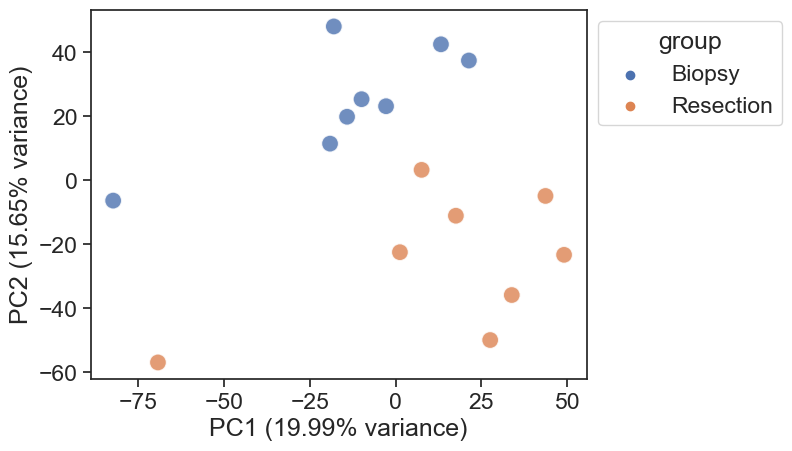

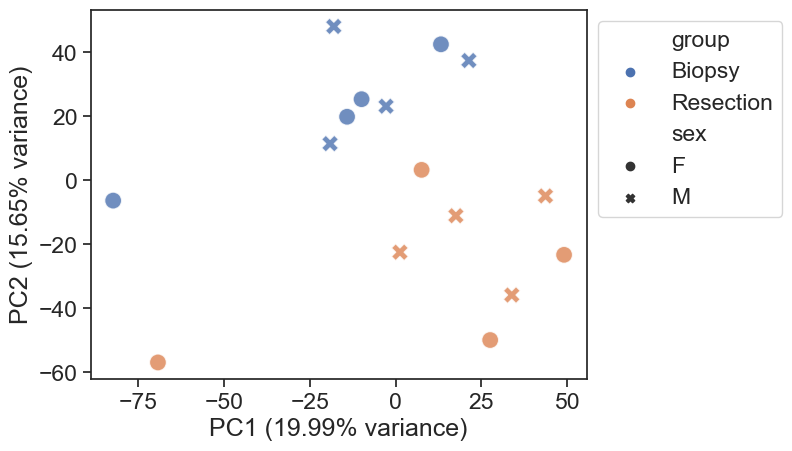

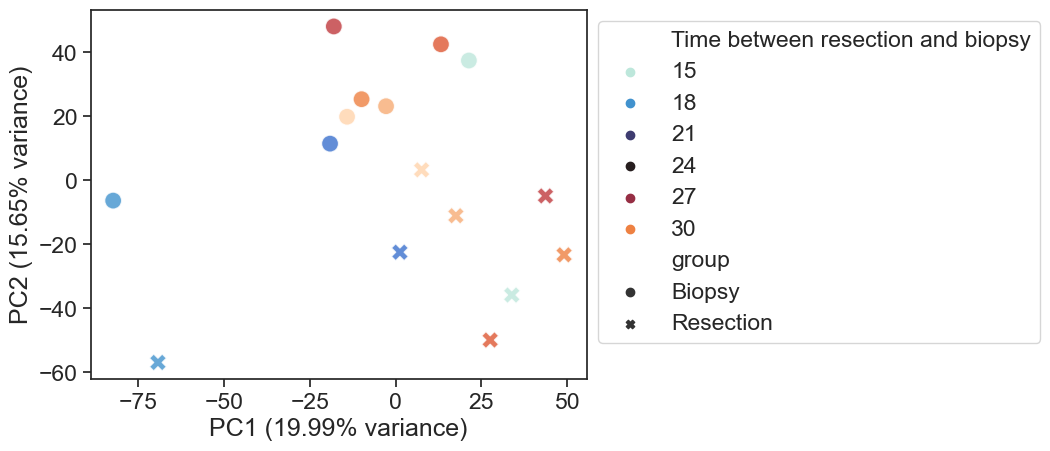

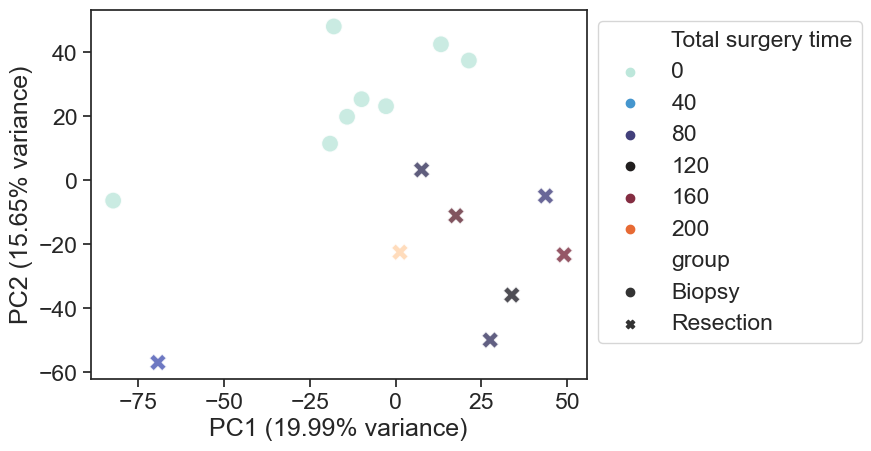

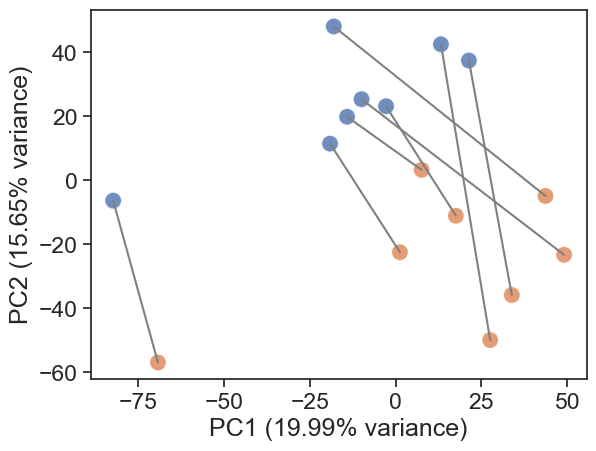

In [53]:
# PCA
used_cols = [x for x in df_liver_imputed.columns if x.startswith('non-tumor')]
scaled = scaler.fit_transform(df_liver_imputed.loc[:,used_cols].T)

pca_data = pca.fit_transform(scaled)

df_pca = pd.DataFrame(pca_data, index=used_cols, columns=['PC1', 'PC2'])
df_pca['group'] = metadata_liver.Sample_type
df_pca['sex'] = metadata_liver.Sex
df_pca['patient_id'] = metadata_liver.patient_id.astype(str)
df_pca['Time between resection and biopsy'] = metadata_liver['Time between resection and biopsy']
df_pca['Total surgery time'] = metadata_liver['Total surgery time']

# Overview
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_liver.pdf', bbox_inches='tight', dpi=300)

#plt.show()

# Sex
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='sex',
                    hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_liver_sex.pdf', bbox_inches='tight', dpi=300)

# Time between B and R
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='group',
                    hue='Time between resection and biopsy', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_liver_timeBvR.pdf', bbox_inches='tight', dpi=300)

# Surgery time
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='group',
                    hue='Total surgery time', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_liver_surgerytime.pdf', bbox_inches='tight', dpi=300)

# Patients
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
h = sns.lineplot(df_pca, x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
plt.legend([],[], frameon=False)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.savefig('figures/PCA_liver_pat.pdf', bbox_inches='tight', dpi=300)

In [54]:
def r2(x, y, ax=None, **kws):
    ax = ax or plt.gca()
    mask = ~np.isnan(x) & ~np.isnan(y)
    slope, intercept, r_value, p_value, std_err = linregress(x[mask], y[mask])
    ax.annotate(f'$r^2 = {r_value ** 2:.2f}$\nEq: ${slope:.2f}x{intercept:+.2f}$\np: ${p_value :.2E}$',
                xy=(.05, .95), xycoords=ax.transAxes, fontsize=8,
                color='darkred', backgroundcolor='#FFFFFF99', ha='left', va='top')

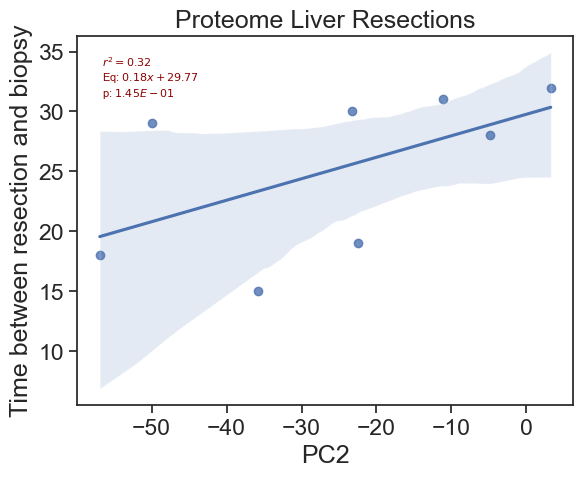

In [55]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Time between resection and biopsy')
r2(df_pca_biop.PC2, df_pca_biop['Time between resection and biopsy'])

plt.title('Proteome Liver Resections')


plt.savefig('figures/corr_pc2_time_b_to_r.pdf', dpi=300, bbox_inches='tight')

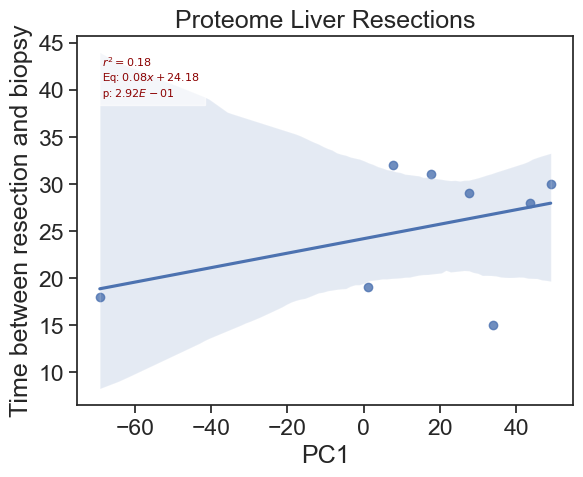

In [56]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Time between resection and biopsy')
r2(df_pca_biop.PC1, df_pca_biop['Time between resection and biopsy'])

plt.title('Proteome Liver Resections')


plt.savefig('figures/corr_pc1_time_b_to_r.pdf', dpi=300, bbox_inches='tight')

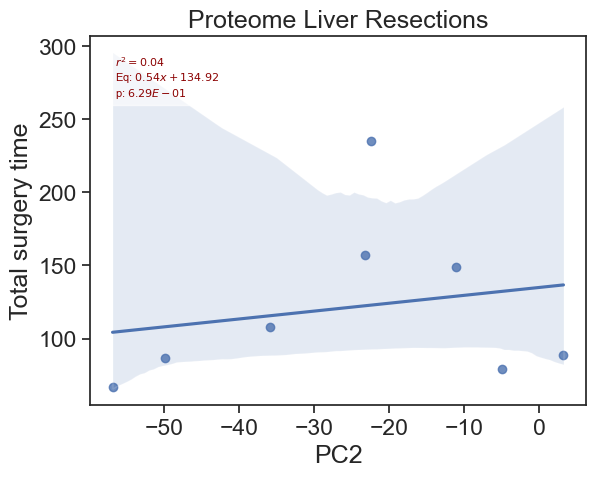

In [57]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Total surgery time')
r2(df_pca_biop.PC2, df_pca_biop['Total surgery time'])

plt.title('Proteome Liver Resections')

plt.savefig('figures/corr_pc2_time_surgery.pdf', dpi=300, bbox_inches='tight')

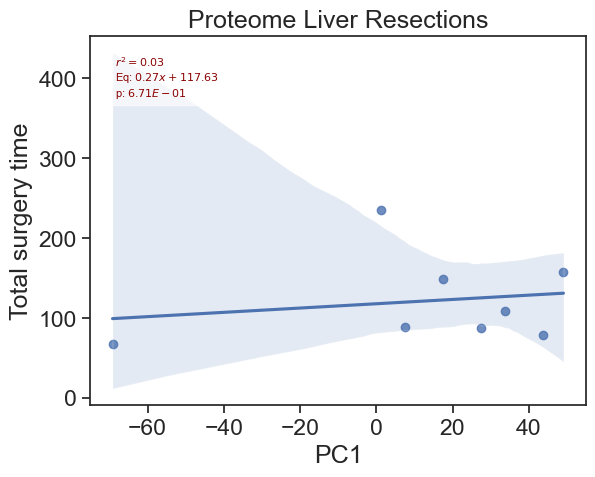

In [58]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Total surgery time')
r2(df_pca_biop.PC1, df_pca_biop['Total surgery time'])

plt.title('Proteome Liver Resections')

plt.savefig('figures/corr_pc1_time_surgery.pdf', dpi=300, bbox_inches='tight')

In [59]:
df_hcc_imputed.head()

,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_L,tumor_Resection_E,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_E
Genes,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A1BG,23.269272,22.434118,23.613062,23.217054,23.983534,22.623493,23.640736,22.401314,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.001875,22.197540,22.382074,22.965267,21.418488,22.457394,22.803585,21.537436,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A1CF,22.497334,21.836653,22.239145,22.393223,22.414202,23.104912,23.120960,21.867062,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.419847,22.134201,22.309052,22.338320,22.874315,22.514940,22.886076,22.513266,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A2M,24.120329,24.303793,26.718737,25.491791,25.300793,22.985004,25.100113,24.121496,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.911610,23.282742,23.423960,24.969208,21.490063,22.733522,23.117685,23.227093,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAAS,17.592808,17.505165,18.431557,18.118654,17.285749,17.919853,17.546719,18.159237,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.254087,17.858549,18.100458,18.081047,17.405237,17.625656,17.072742,17.866768,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AACS,16.722235,16.139231,18.138500,17.459167,16.621637,16.968012,16.965210,16.569284,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,16.915287,16.830183,16.305799,17.302416,16.669680,16.154911,17.504419,16.506622,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0


C:\Users\Fredrik\AppData\Local\Temp\ipykernel_26488\1069209739.py:56: UserWarning: 
The palette list has fewer values (1) than needed (8) and will cycle, which may produce an uninterpretable plot.
  h = sns.lineplot(df_pca, x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)


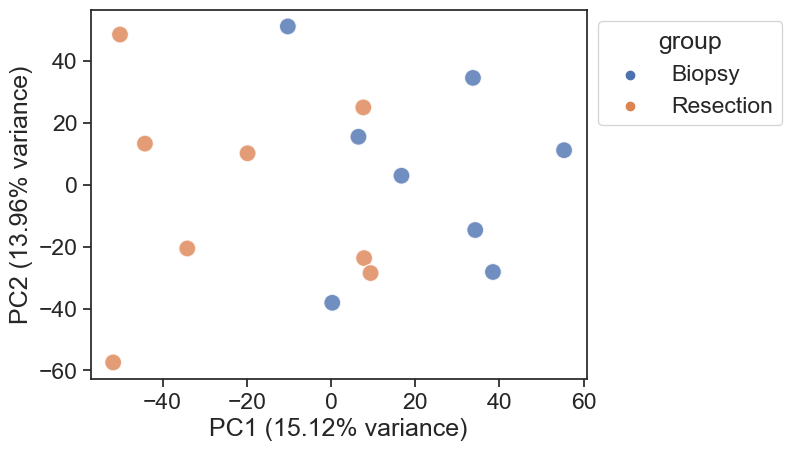

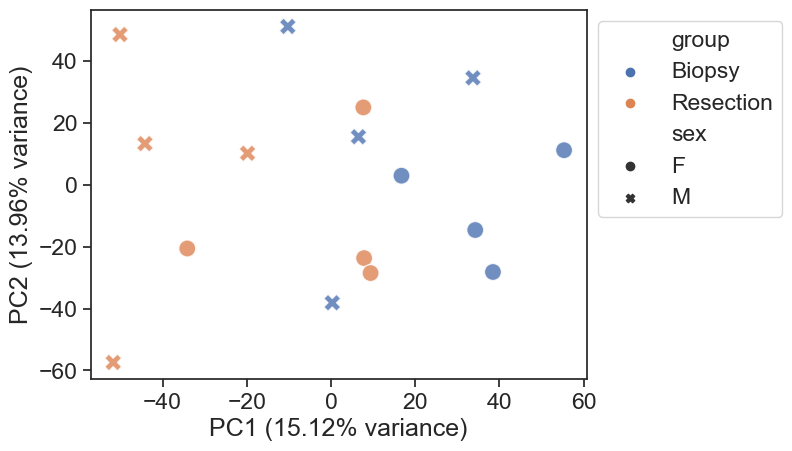

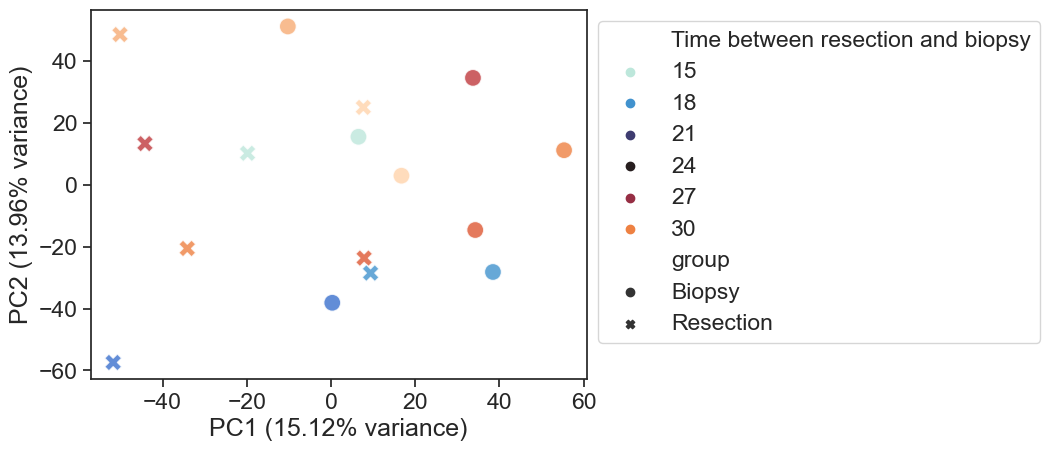

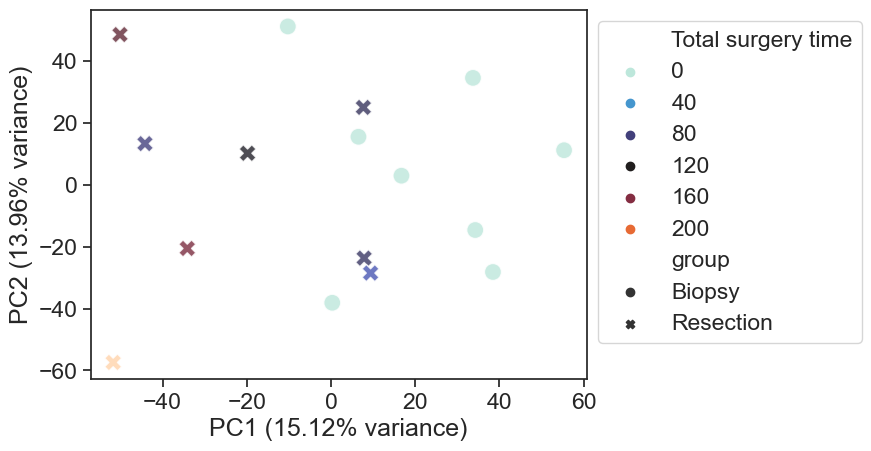

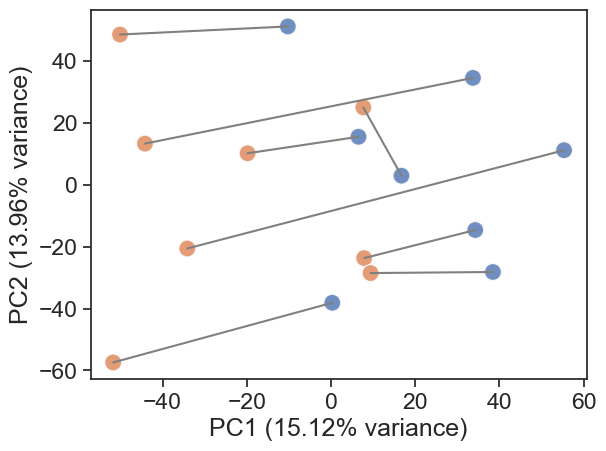

In [60]:
# HCC

# PCA
used_cols = [x for x in df_hcc_imputed.columns if x.startswith('tumor')]
scaled = scaler.fit_transform(df_hcc_imputed.loc[:,used_cols].T)

pca_data = pca.fit_transform(scaled)

df_pca = pd.DataFrame(pca_data, index=used_cols, columns=['PC1', 'PC2'])
df_pca['group'] = metadata_hcc.Sample_type
df_pca['sex'] = metadata_hcc.Sex
df_pca['patient_id'] = metadata_hcc.patient_id.astype(str)
df_pca['Time between resection and biopsy'] = metadata_hcc['Time between resection and biopsy']
df_pca['Total surgery time'] = metadata_hcc['Total surgery time']

# Overview
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_hcc.pdf', bbox_inches='tight', dpi=300)

#plt.show()

# Sex
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='sex',
                    hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_hcc_sex.pdf', bbox_inches='tight', dpi=300)

# Time between B and R
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='group',
                    hue='Time between resection and biopsy', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_hcc_timeBvR.pdf', bbox_inches='tight', dpi=300)

# Surgery time
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='group',
                    hue='Total surgery time', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_hcc_surgerytime.pdf', bbox_inches='tight', dpi=300)

# Patients
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
h = sns.lineplot(df_pca, x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
plt.legend([],[], frameon=False)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.savefig('figures/PCA_hcc_pat.pdf', bbox_inches='tight', dpi=300)

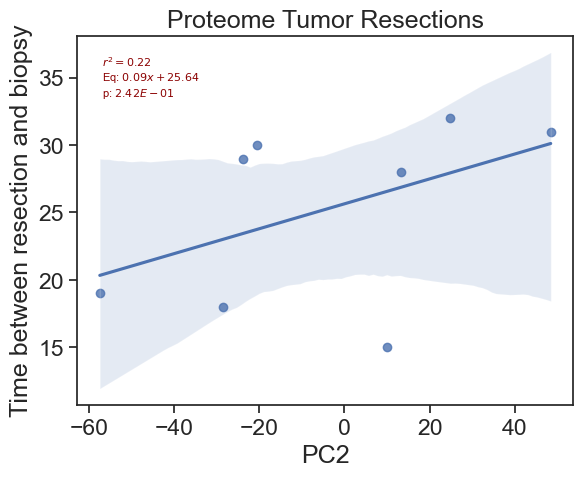

In [61]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Time between resection and biopsy')
r2(df_pca_biop.PC2, df_pca_biop['Time between resection and biopsy'])

plt.title('Proteome Tumor Resections')


plt.savefig('figures/corr_pc2_time_b_to_r_tumor.pdf', dpi=300, bbox_inches='tight')

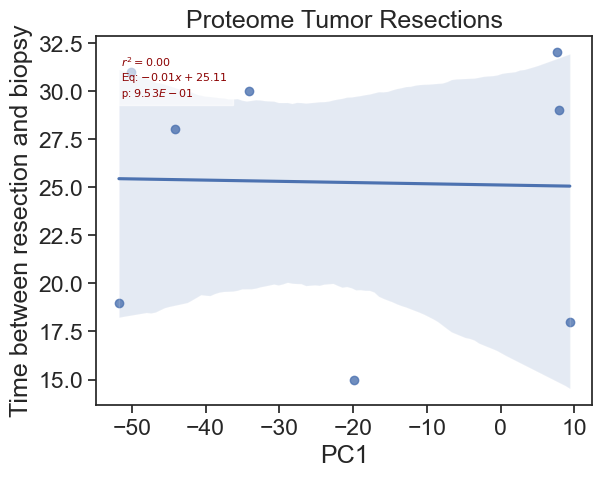

In [62]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Time between resection and biopsy')
r2(df_pca_biop.PC1, df_pca_biop['Time between resection and biopsy'])

plt.title('Proteome Tumor Resections')


plt.savefig('figures/corr_pc1_time_b_to_r_tumor.pdf', dpi=300, bbox_inches='tight')

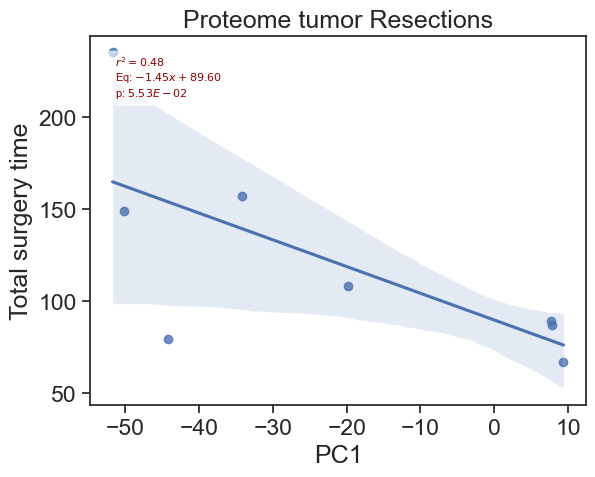

In [63]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Total surgery time')
r2(df_pca_biop.PC1, df_pca_biop['Total surgery time'])

plt.title('Proteome tumor Resections')

plt.savefig('figures/corr_pc1_time_surgery_tumor.pdf', dpi=300, bbox_inches='tight')

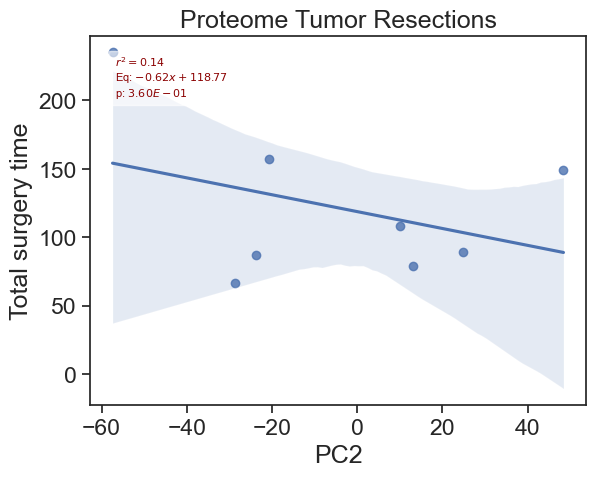

In [64]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Total surgery time')
r2(df_pca_biop.PC2, df_pca_biop['Total surgery time'])

plt.title('Proteome Tumor Resections')

plt.savefig('figures/corr_pc2_time_surgery_tumor.pdf', dpi=300, bbox_inches='tight')

# T-Test

In [68]:
# Helper functions for calculating p-values, adjusted p-values and fold-changes
from scipy import stats

def students_ttest(df, group_cols, control_cols, index_col=None,
                   group_name="group", control_name="control",
                   paired=False, pairing=None):
    """
    Perform Student's t-test (paired or unpaired) between two groups of samples.

    Parameters:
    - df : pandas.DataFrame
        Features as rows, samples as columns.
    - group_cols : list of str
        Column names of the treatment group.
    - control_cols : list of str
        Column names of the control group.
    - index_col : str or None
        If provided, column to set as index in the result.
    - group_name : str
        Label for the group (used in output column names).
    - control_name : str
        Label for the control (used in output column names).
    - paired : bool
        If True, perform paired t-test (requires `pairing`).
    - pairing : pd.Series or None
        Required if `paired=True`. Index = sample names (columns), values = pairing IDs.

    Returns:
    - df_result : pandas.DataFrame
        Contains t-statistics, p-values, adjusted p-values, and fold changes.
    """
    df_ = df.copy()

    if paired:
        if pairing is None:
            raise ValueError("Pairing metadata must be provided for paired t-test.")
        # Map pair IDs to columns for each group
        group_pairs = pairing.loc[group_cols]
        control_pairs = pairing.loc[control_cols]

        # Find common pair IDs between group and control
        common_pairs = group_pairs[group_pairs.isin(control_pairs.values)].unique()
        if len(common_pairs) == 0:
            raise ValueError("No matching pair IDs found between group and control.")

        # Align columns based on common pair IDs
        group_aligned = [col for col in group_cols if pairing[col] in common_pairs]
        control_aligned = [col for col in control_cols if pairing[col] in common_pairs]
        
        # Map from pair ID to column
        group_map = {pairing[col]: col for col in group_aligned}
        control_map = {pairing[col]: col for col in control_aligned}
        shared_pairs = sorted(set(group_map.keys()) & set(control_map.keys()))

        group_cols_final = [group_map[p] for p in shared_pairs]
        control_cols_final = [control_map[p] for p in shared_pairs]

        if len(group_cols_final) != len(control_cols_final):
            raise ValueError("Aligned paired samples are not the same length.")

        # Paired t-test
        tstats, pvals = stats.ttest_rel(
            df_[group_cols_final].values,
            df_[control_cols_final].values,
            axis=1,
            nan_policy='propagate'
        )
        fold_change = df_[group_cols_final].mean(axis=1) - df_[control_cols_final].mean(axis=1)
    else:
        # Unpaired t-test
        ttest_result = stats.ttest_ind(
            df_[group_cols],
            df_[control_cols],
            axis=1,
            nan_policy='propagate'
        )
        tstats = ttest_result.statistic
        pvals = ttest_result.pvalue
        fold_change = df_[group_cols].mean(axis=1) - df_[control_cols].mean(axis=1)

    label = f"{group_name}vs{control_name}"
    stats_col = f"{label}_tstat"
    pval_col = f"{label}_pval"
    adj_pval_col = f"{label}_adj_pval"
    fc_col = f"{label}_fc"

    # Build result table
    df_[stats_col] = tstats
    df_[pval_col] = pvals
    df_[fc_col] = fold_change

    # Multiple testing correction (Benjamini-Hochberg)
    df_ = df_.sort_values(pval_col).reset_index(names='ID')
    n = df_.shape[0]
    ranks = np.arange(1, n + 1)
    bh_adj = df_[pval_col] * n / ranks
    df_[adj_pval_col] = np.minimum.accumulate(bh_adj[::-1])[::-1].clip(upper=1.0)


    df_.index = df_.ID  # preserve original

    return df_


def power_to_transform(x):
    return 10 ** -x
def neg_log10(x):
    return np.log10(1/x)

In [69]:
df_liver_imputed.columns

Index(['non-tumor_Biopsy_D', 'non-tumor_Biopsy_N', 'non-tumor_Biopsy_O',
       'non-tumor_Biopsy_Q', 'non-tumor_Biopsy_I', 'non-tumor_Biopsy_T',
       'non-tumor_Biopsy_L', 'non-tumor_Biopsy_E',
       'missingindicator_non-tumor_Biopsy_D',
       'missingindicator_non-tumor_Biopsy_N',
       'missingindicator_non-tumor_Biopsy_O',
       'missingindicator_non-tumor_Biopsy_Q',
       'missingindicator_non-tumor_Biopsy_I',
       'missingindicator_non-tumor_Biopsy_T',
       'missingindicator_non-tumor_Biopsy_L',
       'missingindicator_non-tumor_Biopsy_E', 'non-tumor_Resection_D',
       'non-tumor_Resection_N', 'non-tumor_Resection_O',
       'non-tumor_Resection_Q', 'non-tumor_Resection_T',
       'non-tumor_Resection_I', 'non-tumor_Resection_L',
       'non-tumor_Resection_E', 'missingindicator_non-tumor_Resection_D',
       'missingindicator_non-tumor_Resection_N',
       'missingindicator_non-tumor_Resection_O',
       'missingindicator_non-tumor_Resection_Q',
       'missingind

In [70]:
res = students_ttest(
    df=df_liver_imputed,
    group_cols=metadata_liver[metadata_liver.Sample_type == 'Resection'].index,
    control_cols=metadata_liver[metadata_liver.Sample_type == 'Biopsy'].index,
    group_name="Resection",
    control_name="Biopsy",
    paired=True,
    pairing=metadata_liver.patient_id,
)


In [71]:
res['-log10 pval'] = -np.log10(res['ResectionvsBiopsy_pval'])

In [72]:
res = res.rename({'ID':'Gene'}, axis=1)
res.head()

,Gene,non-tumor_Biopsy_D,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_I,non-tumor_Biopsy_T,non-tumor_Biopsy_L,non-tumor_Biopsy_E,missingindicator_non-tumor_Biopsy_D,missingindicator_non-tumor_Biopsy_N,missingindicator_non-tumor_Biopsy_O,missingindicator_non-tumor_Biopsy_Q,missingindicator_non-tumor_Biopsy_I,missingindicator_non-tumor_Biopsy_T,missingindicator_non-tumor_Biopsy_L,missingindicator_non-tumor_Biopsy_E,non-tumor_Resection_D,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,non-tumor_Resection_I,non-tumor_Resection_L,non-tumor_Resection_E,missingindicator_non-tumor_Resection_D,missingindicator_non-tumor_Resection_N,missingindicator_non-tumor_Resection_O,missingindicator_non-tumor_Resection_Q,missingindicator_non-tumor_Resection_T,missingindicator_non-tumor_Resection_I,missingindicator_non-tumor_Resection_L,missingindicator_non-tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval,-log10 pval
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
SERPINA10,SERPINA10,15.739415,15.964828,15.913012,16.105091,16.064407,16.128073,16.034681,15.737544,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,19.734535,19.767988,20.022377,20.110924,20.109262,19.893181,19.670513,19.998957,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,57.631745,1.242505e-10,3.952586,7.673712e-07,9.905702
ATF2,ATF2,15.123445,15.051240,15.713200,15.838482,15.578964,15.768139,15.794566,15.519250,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,19.734535,19.767988,20.022377,20.110924,20.109262,19.893181,19.670513,19.998957,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,48.615976,4.076864e-10,4.365055,1.258936e-06,9.389674
RBMX2,RBMX2,20.125048,20.247885,20.231792,19.846701,19.731560,19.967525,19.954592,20.286728,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,15.566314,15.292962,15.875984,15.448501,15.821537,14.944395,15.491985,16.177385,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,-43.311620,9.130857e-10,-4.471596,1.700209e-06,9.039488
SGF29,SGF29,20.125048,20.247885,20.231792,19.846701,19.731560,19.967525,19.954592,20.286728,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,15.850284,15.607041,15.628044,15.817657,15.545865,15.895706,15.454329,16.231161,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,-41.073664,1.322015e-09,-4.295218,1.700209e-06,8.878764
ZNF384,ZNF384,20.125048,20.247885,20.231792,19.846701,19.731560,19.967525,19.954592,20.286728,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,15.605254,15.968433,15.347466,15.224769,16.037697,15.019958,15.745133,15.676571,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,-40.836645,1.376464e-09,-4.470819,1.700209e-06,8.861235


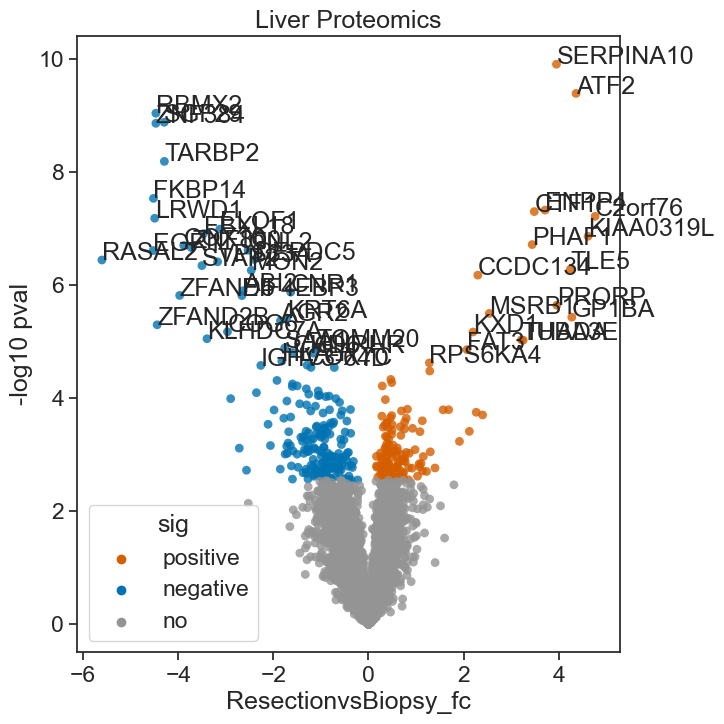

In [73]:
df_ttest_ = res.copy()

df_ttest_['sig'] = np.where((df_ttest_['ResectionvsBiopsy_adj_pval'] < 0.05) &\
                            (df_ttest_['ResectionvsBiopsy_fc'] > 0), 'positive',
                    np.where((df_ttest_['ResectionvsBiopsy_adj_pval'] < 0.05) &\
                             (df_ttest_['ResectionvsBiopsy_fc'] < 0), 'negative', 
                                    'no'))

fig, ax = plt.subplots(figsize=(7,8))

colors = sns.color_palette('colorblind')

sns.scatterplot(data=df_ttest_, x='ResectionvsBiopsy_fc', y='-log10 pval',
                hue='sig', alpha=0.8, linewidth=0, palette=[colors[3], colors[0], colors[7]],
                hue_order=['positive', 'negative', 'no'], s=40)

most_sig = df_ttest_.sort_values('-log10 pval', ascending=False)
                

for i in range(0,50):
    x = most_sig.iloc[i,:]['ResectionvsBiopsy_fc'].item()
    y = most_sig.iloc[i,:]['-log10 pval'].item()
    label = most_sig.iloc[i,:]['Gene'] 
    plt.text(x=x, y=y, s=label)
    
plt.title('Liver Proteomics')
#plt.show()
plt.savefig('Volcano_proteomics_liver_output.pdf', bbox_inches='tight', dpi=300)

In [74]:
df_ttest_.to_csv(f'prot_ttest_liver_{today}.csv')

In [75]:
# corr_times = pd.concat([df_liver_imputed.loc[most_sig.iloc[:12,:].index,:].T, metadata_liver['Total surgery time']], axis=1)
# corr_times = corr_times[corr_times['Total surgery time'] > 0]

# new_cols = corr_times.columns[:-1].map(df_liver_imputed.Gene).tolist()
# new_cols.append('Total surgery time')

# new_cols_ = []
# for col in new_cols:
#     n = col.replace(';', '_')
#     new_cols_.append(n)

# corr_times.columns = new_cols_
# corr_times['Total surgery time'] = corr_times['Total surgery time'].astype(int)
# #print(corr_times[:-1])
# corr_times.iloc[:,:-1] = corr_times.iloc[:,:-1].astype(float)
# corr_times.isna().sum()
# sns.barplot(corr_times.corrwith(corr_times['Total surgery time'])[:-1], orient='h')
# # plt.ylabel('Top DEGs')
# # plt.xlabel('Pearson Correlation')
# # plt.title('VST expression VS total surgery time')

# # plt.savefig('figures/top_degs_corr_surgery_time_liver.pdf', dpi=300, bbox_inches='tight')

In [76]:
msig = Msigdb()
#gmt = msig.get_gmt(category='h.all', dbver="2025.1.Hs")

gmt = msig.get_gmt(category='c2.all', dbver="2025.1.Hs")

In [77]:
#msig.list_dbver()

In [78]:
#msig.list_category()

In [79]:
df_liver_sig = most_sig[most_sig.sig != 'no'].copy()
df_liver_sig.shape

(346, 39)

In [80]:
#df_liver_sig.Gene.tolist()

In [81]:
new_sig_genes = set()
for gene in df_liver_sig.Gene.tolist():
    if ';' in gene:
        genes = gene.split(';')
        
        for g in genes:
            new_sig_genes.add(g)
    else:
        new_sig_genes.add(gene)

In [82]:
# HCC

In [83]:
res = students_ttest(
    df=df_hcc_imputed,
    group_cols=metadata_hcc[metadata_hcc.Sample_type == 'Resection'].index,
    control_cols=metadata_hcc[metadata_hcc.Sample_type == 'Biopsy'].index,
    group_name="Resection",
    control_name="Biopsy",
    paired=True,
    pairing=metadata_hcc.patient_id,
)

In [84]:
res.head()

,ID,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_L,tumor_Resection_E,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ZNF768,ZNF768,19.883181,19.446518,20.386578,19.586206,20.286194,19.596546,20.083742,19.441967,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,13.630860,14.087168,13.597336,13.591312,14.114967,13.690052,13.579862,13.925812,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,-30.731739,9.969814e-09,-6.061696,0.000041
SETDB1,SETDB1,19.883181,19.446518,20.386578,19.586206,20.286194,19.596546,20.083742,19.441967,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,14.451080,14.289857,14.409370,13.703611,14.315837,14.720226,15.594678,14.620420,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,-29.801938,1.234399e-08,-5.325732,0.000041
TEKTL1,TEKTL1,19.883181,19.446518,20.386578,19.586206,20.286194,19.596546,20.083742,19.441967,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,16.195124,15.923978,16.606485,16.588369,16.140877,15.831885,16.650600,15.465838,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,-24.076467,5.425074e-08,-3.663471,0.000082
KIAA0319L,KIAA0319L,14.900221,14.505871,15.595763,14.679104,15.107142,15.077008,15.947177,14.950027,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,19.870106,19.489981,19.301390,19.677645,19.362446,19.420925,19.702492,19.328909,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,23.778418,5.913814e-08,4.423948,0.000082
DVL3,DVL3,19.883181,19.446518,20.386578,19.586206,20.286194,19.596546,20.083742,19.441967,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,15.905124,15.326572,15.644899,16.039597,14.696165,16.456867,15.816138,15.849239,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,-23.461250,6.489937e-08,-4.122042,0.000082


In [85]:
df_hcc_imputed.head()

,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_L,tumor_Resection_E,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_E
Genes,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A1BG,23.269272,22.434118,23.613062,23.217054,23.983534,22.623493,23.640736,22.401314,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.001875,22.197540,22.382074,22.965267,21.418488,22.457394,22.803585,21.537436,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A1CF,22.497334,21.836653,22.239145,22.393223,22.414202,23.104912,23.120960,21.867062,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.419847,22.134201,22.309052,22.338320,22.874315,22.514940,22.886076,22.513266,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A2M,24.120329,24.303793,26.718737,25.491791,25.300793,22.985004,25.100113,24.121496,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.911610,23.282742,23.423960,24.969208,21.490063,22.733522,23.117685,23.227093,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAAS,17.592808,17.505165,18.431557,18.118654,17.285749,17.919853,17.546719,18.159237,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.254087,17.858549,18.100458,18.081047,17.405237,17.625656,17.072742,17.866768,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AACS,16.722235,16.139231,18.138500,17.459167,16.621637,16.968012,16.965210,16.569284,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,16.915287,16.830183,16.305799,17.302416,16.669680,16.154911,17.504419,16.506622,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0


In [86]:
res['-log10 pval'] = -np.log10(res['ResectionvsBiopsy_pval'])

In [87]:
res = res.rename({'ID':'Gene'}, axis=1)
res.head()

,Gene,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_L,tumor_Resection_E,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval,-log10 pval
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ZNF768,ZNF768,19.883181,19.446518,20.386578,19.586206,20.286194,19.596546,20.083742,19.441967,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,13.630860,14.087168,13.597336,13.591312,14.114967,13.690052,13.579862,13.925812,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,-30.731739,9.969814e-09,-6.061696,0.000041,8.001313
SETDB1,SETDB1,19.883181,19.446518,20.386578,19.586206,20.286194,19.596546,20.083742,19.441967,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,14.451080,14.289857,14.409370,13.703611,14.315837,14.720226,15.594678,14.620420,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,-29.801938,1.234399e-08,-5.325732,0.000041,7.908544
TEKTL1,TEKTL1,19.883181,19.446518,20.386578,19.586206,20.286194,19.596546,20.083742,19.441967,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,16.195124,15.923978,16.606485,16.588369,16.140877,15.831885,16.650600,15.465838,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,-24.076467,5.425074e-08,-3.663471,0.000082,7.265594
KIAA0319L,KIAA0319L,14.900221,14.505871,15.595763,14.679104,15.107142,15.077008,15.947177,14.950027,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,19.870106,19.489981,19.301390,19.677645,19.362446,19.420925,19.702492,19.328909,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,23.778418,5.913814e-08,4.423948,0.000082,7.228132
DVL3,DVL3,19.883181,19.446518,20.386578,19.586206,20.286194,19.596546,20.083742,19.441967,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,15.905124,15.326572,15.644899,16.039597,14.696165,16.456867,15.816138,15.849239,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,-23.461250,6.489937e-08,-4.122042,0.000082,7.187760


In [88]:
res.head()

,Gene,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_L,tumor_Resection_E,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval,-log10 pval
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ZNF768,ZNF768,19.883181,19.446518,20.386578,19.586206,20.286194,19.596546,20.083742,19.441967,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,13.630860,14.087168,13.597336,13.591312,14.114967,13.690052,13.579862,13.925812,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,-30.731739,9.969814e-09,-6.061696,0.000041,8.001313
SETDB1,SETDB1,19.883181,19.446518,20.386578,19.586206,20.286194,19.596546,20.083742,19.441967,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,14.451080,14.289857,14.409370,13.703611,14.315837,14.720226,15.594678,14.620420,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,-29.801938,1.234399e-08,-5.325732,0.000041,7.908544
TEKTL1,TEKTL1,19.883181,19.446518,20.386578,19.586206,20.286194,19.596546,20.083742,19.441967,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,16.195124,15.923978,16.606485,16.588369,16.140877,15.831885,16.650600,15.465838,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,-24.076467,5.425074e-08,-3.663471,0.000082,7.265594
KIAA0319L,KIAA0319L,14.900221,14.505871,15.595763,14.679104,15.107142,15.077008,15.947177,14.950027,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,19.870106,19.489981,19.301390,19.677645,19.362446,19.420925,19.702492,19.328909,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,23.778418,5.913814e-08,4.423948,0.000082,7.228132
DVL3,DVL3,19.883181,19.446518,20.386578,19.586206,20.286194,19.596546,20.083742,19.441967,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,15.905124,15.326572,15.644899,16.039597,14.696165,16.456867,15.816138,15.849239,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,-23.461250,6.489937e-08,-4.122042,0.000082,7.187760


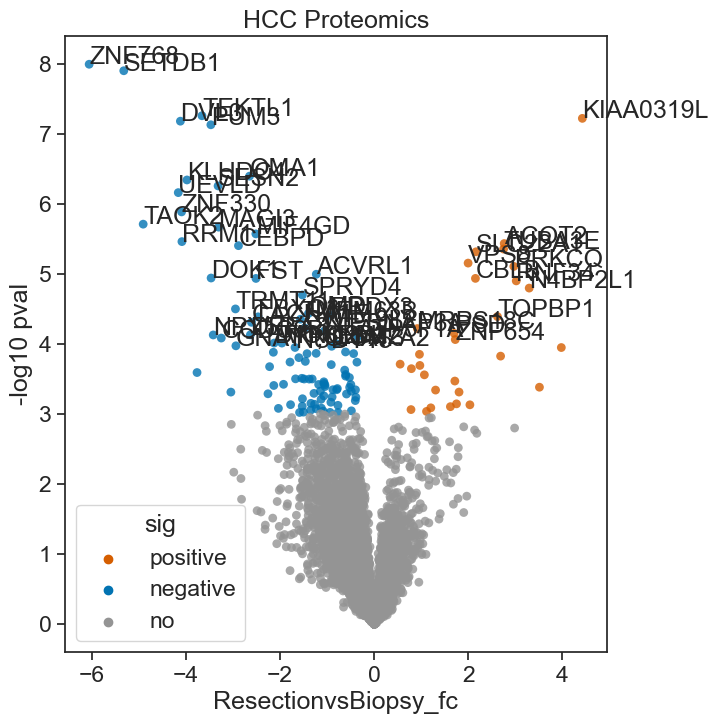

In [89]:
df_ttest_ = res.copy()

df_ttest_['sig'] = np.where((df_ttest_['ResectionvsBiopsy_adj_pval'] < 0.05) &\
                            (df_ttest_['ResectionvsBiopsy_fc'] > 0), 'positive',
                    np.where((df_ttest_['ResectionvsBiopsy_adj_pval'] < 0.05) &\
                             (df_ttest_['ResectionvsBiopsy_fc'] < 0), 'negative', 
                                    'no'))

fig, ax = plt.subplots(figsize=(7,8))

colors = sns.color_palette('colorblind')

sns.scatterplot(data=df_ttest_, x='ResectionvsBiopsy_fc', y='-log10 pval',
                hue='sig', alpha=0.8, linewidth=0, palette=[colors[3], colors[0], colors[7]],
                hue_order=['positive', 'negative', 'no'], s=40)

most_sig = df_ttest_.sort_values('-log10 pval', ascending=False)

for i in range(0,50):
    x = most_sig.iloc[i,:]['ResectionvsBiopsy_fc'].item()
    y = most_sig.iloc[i,:]['-log10 pval'].item()
    label = most_sig.iloc[i,:]['Gene'] 
    plt.text(x=x, y=y, s=label)
    
plt.title('HCC Proteomics')
#plt.show()
plt.savefig('Volcano_proteomics_hcc_output.pdf', bbox_inches='tight', dpi=300)

In [90]:
df_ttest_.to_csv(f'prot_ttest_hcc_{today}.csv')

In [101]:
df_hcc_sig = most_sig[most_sig.sig != 'no'].copy()
df_hcc_sig.shape

(129, 39)

In [102]:
df_hcc_sig

,Gene,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_L,tumor_Resection_E,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval,-log10 pval,sig
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ZNF768,ZNF768,19.883181,19.446518,20.386578,19.586206,20.286194,19.596546,20.083742,19.441967,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,13.630860,14.087168,13.597336,13.591312,14.114967,13.690052,13.579862,13.925812,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,-30.731739,9.969814e-09,-6.061696,0.000041,8.001313,negative
SETDB1,SETDB1,19.883181,19.446518,20.386578,19.586206,20.286194,19.596546,20.083742,19.441967,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,14.451080,14.289857,14.409370,13.703611,14.315837,14.720226,15.594678,14.620420,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,-29.801938,1.234399e-08,-5.325732,0.000041,7.908544,negative
TEKTL1,TEKTL1,19.883181,19.446518,20.386578,19.586206,20.286194,19.596546,20.083742,19.441967,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,16.195124,15.923978,16.606485,16.588369,16.140877,15.831885,16.650600,15.465838,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,-24.076467,5.425074e-08,-3.663471,0.000082,7.265594,negative
KIAA0319L,KIAA0319L,14.900221,14.505871,15.595763,14.679104,15.107142,15.077008,15.947177,14.950027,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,19.870106,19.489981,19.301390,19.677645,19.362446,19.420925,19.702492,19.328909,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,23.778418,5.913814e-08,4.423948,0.000082,7.228132,positive
DVL3,DVL3,19.883181,19.446518,20.386578,19.586206,20.286194,19.596546,20.083742,19.441967,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,15.905124,15.326572,15.644899,16.039597,14.696165,16.456867,15.816138,15.849239,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,-23.461250,6.489937e-08,-4.122042,0.000082,7.187760,negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SMARCD3,SMARCD3,18.745928,18.829281,17.844877,17.988558,18.833448,17.660475,18.027632,17.908035,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,19.634523,19.049274,18.989073,19.698830,19.189409,19.363831,19.888170,18.913706,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,5.496454,9.099500e-04,1.111073,0.048751,3.040982,positive
ATM,ATM,18.095844,18.552273,18.198130,18.244715,18.145895,17.774475,18.103405,18.645311,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,16.101036,16.634760,16.409187,17.053062,17.016191,17.378708,17.376028,15.747228,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-5.473688,9.322004e-04,-1.505482,0.048960,3.030491,negative
PTBP2,PTBP2,17.287840,16.385590,17.016729,16.685608,18.616785,17.834795,18.884781,17.779730,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,16.581278,15.649669,16.074390,16.550486,16.300987,17.983202,17.544497,16.288458,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,-5.467780,9.380728e-04,-0.939863,0.048960,3.027763,negative


In [103]:
new_sig_genes = set()
for gene in df_hcc_sig.Gene.tolist():
    if ';' in gene:
        genes = gene.split(';')
        
        for g in genes:
            new_sig_genes.add(g)
    else:
        new_sig_genes.add(gene)

In [104]:
new_sig_genes

{'ACOT2',
 'ACOT4',
 'ACVRL1',
 'ADAMTS3',
 'ALPK3',
 'ANGPTL4',
 'ANK2',
 'ATM',
 'ATP5F1A',
 'ATP5ME',
 'BCL6',
 'BPNT2',
 'CA13',
 'CACNA1E',
 'CBLB',
 'CCDC85C',
 'CCDC9B',
 'CCM2',
 'CDC42BPA',
 'CDC42SE2',
 'CEBPD',
 'CHSY3',
 'COX7A2',
 'COX7C',
 'CPN1',
 'CWC15',
 'CWF19L2',
 'DEFA3',
 'DOK1',
 'DTD2',
 'DVL3',
 'DYNC2H1',
 'EDC3',
 'ELOF1',
 'FBXO3',
 'FCGBP',
 'FCGR2C',
 'FST',
 'GABBR1',
 'GABPB1',
 'GDF15',
 'GNAT1',
 'GNAT3',
 'GNL3L',
 'GP1BA',
 'GSTO1',
 'IGFALS',
 'IGHV3-43',
 'IGHV3-72',
 'IGHV4-30-4',
 'IGHV4-34',
 'IGHV4-38-2',
 'IGHV4-39',
 'IGHV4-59',
 'IGHV4-61',
 'IGKV1-8',
 'IGKV4-1',
 'IGLV9-49',
 'IKBKB',
 'KDM6B',
 'KIAA0319L',
 'KLHDC4',
 'KRAS',
 'KRT14',
 'LSM2',
 'MAGI3',
 'MAP7D3',
 'MAST4',
 'MIF4GD',
 'MOB4',
 'MOSPD2',
 'MRPS18C',
 'MYRIP',
 'N4BP2L1',
 'NCBP2',
 'NCEH1',
 'NF1',
 'NIPSNAP3A',
 'NOTUM',
 'NPY5R',
 'NUDT15',
 'OMA1',
 'OMD',
 'OSBPL1A',
 'PHB2',
 'PLEKHA2',
 'PRDX3',
 'PRKCQ',
 'PRSS1',
 'PSD',
 'PSMA3',
 'PSMA5',
 'PTBP2',
 'PTN',
 'P

In [105]:
try:
    enr_res = gp.enrichr(gene_list=new_sig_genes,
     gene_sets=gmt,
     organism='Homo Sapiens',
     outdir='C2/',
     background=bg_genes,
     )
except:
    print('no sig pathways')

no sig pathways


In [106]:
df_heatmap_l = df_liver_sig.iloc[:,-6:].copy()
df_heatmap_h = df_hcc_sig.iloc[:,-6:].copy()

df_heatmap_l = df_heatmap_l.drop(['ResectionvsBiopsy_tstat', 'ResectionvsBiopsy_pval',
                                  'ResectionvsBiopsy_adj_pval'], axis=1)

df_heatmap_h = df_heatmap_h.drop(['ResectionvsBiopsy_tstat', 'ResectionvsBiopsy_pval',
                                  'ResectionvsBiopsy_adj_pval'], axis=1)

df_heatmap = df_heatmap_l.merge(df_heatmap_h, left_index=True, right_index=True, suffixes=('_liver', '_hcc'), how='outer')
#df_heatmap.index = df_heatmap.Gene_liver
df_heatmap.head()

,ResectionvsBiopsy_fc_liver,-log10 pval_liver,sig_liver,ResectionvsBiopsy_fc_hcc,-log10 pval_hcc,sig_hcc
ID,,,,,,
ABCD1,-0.948418,2.580310,negative,NaN,NaN,NaN
ABCF3,-0.317493,2.880368,negative,NaN,NaN,NaN
ABHD14A,-0.862553,2.779222,negative,NaN,NaN,NaN
ABI2,-2.633720,5.900106,negative,NaN,NaN,NaN
ACIN1,0.262400,2.962397,positive,NaN,NaN,NaN


In [107]:
df_heatmap.isna().sum()

ResectionvsBiopsy_fc_liver    107
-log10 pval_liver             107
sig_liver                     107
ResectionvsBiopsy_fc_hcc      324
-log10 pval_hcc               324
sig_hcc                       324
dtype: int64

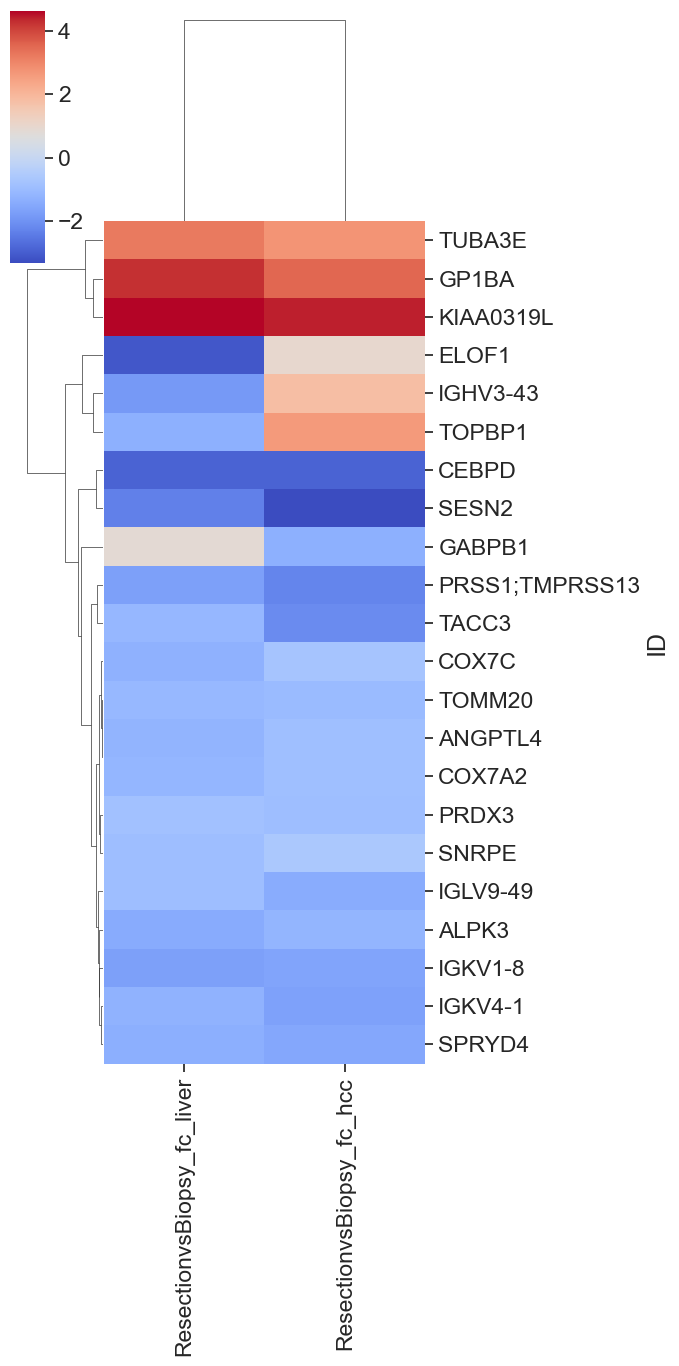

In [110]:
df_heatmap_ = df_heatmap.dropna()
sns.clustermap(df_heatmap_.loc[:,['ResectionvsBiopsy_fc_liver', 'ResectionvsBiopsy_fc_hcc']],
           cmap='coolwarm', yticklabels=True, figsize=(7,14))

In [111]:
def r2(x, y, ax=None, **kws):
    ax = ax or plt.gca()
    mask = ~np.isnan(x) & ~np.isnan(y)
    slope, intercept, r_value, p_value, std_err = linregress(x[mask], y[mask])
    ax.annotate(f'$r^2 = {r_value ** 2:.2f}$\nEq: ${slope:.2f}x{intercept:+.2f}$\np: ${p_value :.2E}$',
                xy=(.05, .95), xycoords=ax.transAxes, fontsize=8,
                color='darkred', backgroundcolor='#FFFFFF99', ha='left', va='top')

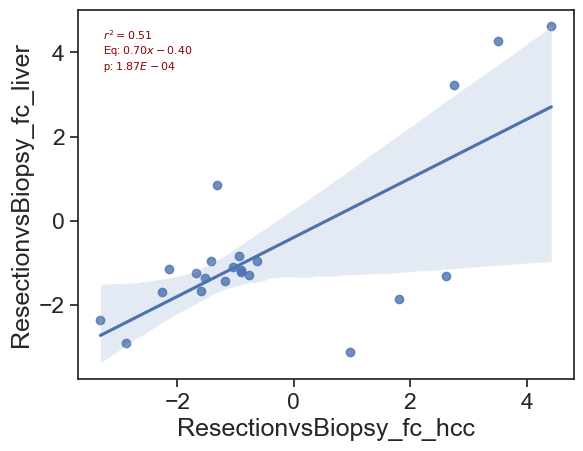

In [112]:
sns.regplot(df_heatmap_, x='ResectionvsBiopsy_fc_hcc', y='ResectionvsBiopsy_fc_liver' )

r2(df_heatmap.ResectionvsBiopsy_fc_hcc, df_heatmap.ResectionvsBiopsy_fc_liver)
plt.savefig('figures/Correlations_proteome.pdf', dpi=300, bbox_inches='tight')

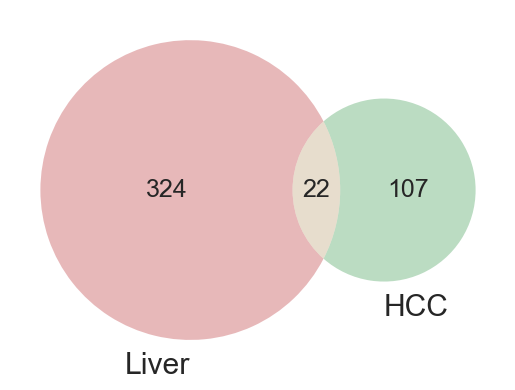

In [113]:
from matplotlib_venn import venn2

set1 = set(df_heatmap.ResectionvsBiopsy_fc_liver.dropna().index)
set2 = set(df_heatmap.ResectionvsBiopsy_fc_hcc.dropna().index)

venn2([set1, set2], ('Liver', 'HCC'))

plt.savefig('figures/venn_proteome.pdf', dpi=300, bbox_inches='tight')

In [115]:
df_out = pd.concat([df_liver_imputed, df_hcc_imputed, df_heatmap], axis=1)

In [114]:
df_out.to_csv('Biopsy_resection_Proteomics_ttest_05122025.csv')